<a href="https://colab.research.google.com/github/TiagoTBarreto/MMM_VAREJO_360/blob/main/Case_Tecnico_Uncover_MMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.0 Imports

In [1]:
!pip install prophet -q

In [74]:
from prophet import Prophet
from google.colab import drive

from plotly.subplots import make_subplots
from matplotlib.ticker import ScalarFormatter



from statsmodels.tsa.seasonal import STL
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.patches as mpatches

In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)

## 0.1 Funções

In [4]:
# Adstock (geometric decay)
def adstock(x, alpha):
    result = np.zeros(len(x))
    result[0] = x.iloc[0]

    for t in range(1, len(x)):
        result[t] = x.iloc[t] + alpha * result[t-1]

    return result


# Lag (shift)
def lag(x, l):
    return pd.Series(x).shift(l).fillna(0).values


# Hill Function / Saturation (diminishing returns)
def hill_function(x, k, s):
    x = np.maximum(x, 0)  # avoid negative values
    return (x**s) / (x**s + k**s + 1e-9)

## 0.2 Google Drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
with open('/content/drive/MyDrive/.github_token', 'r') as f:
    token = f.read().strip()


os.environ['GITHUB_TOKEN'] = token

In [7]:
!git clone https://$GITHUB_TOKEN@github.com/TiagoTBarreto/MMM_VAREJO_360.git
!git config --global user.email "tiagotavaresbarreto@gmail.com"
!git config --global user.name "Tiago Barreto"

Cloning into 'MMM_VAREJO_360'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 90 (delta 36), reused 32 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 3.13 MiB | 11.64 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [8]:
!cd MMM_VAREJO_360/

In [9]:
!ls -l

total 12
drwx------ 6 root root 4096 May  7 22:21 drive
drwxr-xr-x 4 root root 4096 May  7 22:21 MMM_VAREJO_360
drwxr-xr-x 1 root root 4096 Apr 16 13:28 sample_data


## 0.3 Loading Dataset

In [10]:
df_raw = pd.read_csv('MMM_VAREJO_360/data/varejo360_weekly.csv')

# 1.0 Data Description

In [11]:
df1 = df_raw.copy()

## 1.1 Datatypes

In [12]:
df1.dtypes

,0
date,object
units_sold,int64
revenue_brl,float64
avg_price_brl,float64
tv_spend_brl,float64
google_search_spend_brl,float64
google_display_spend_brl,float64
meta_spend_brl,float64
ooh_spend_brl,float64
email_crm_sends,int64


## 1.2 Check NA

In [13]:
df1.isna().sum()

,0
date,0
units_sold,0
revenue_brl,0
avg_price_brl,0
tv_spend_brl,0
google_search_spend_brl,0
google_display_spend_brl,0
meta_spend_brl,0
ooh_spend_brl,0
email_crm_sends,0


## 1.3 Change Datatypes

In [14]:
df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')

## 1.4 Basic Descriptive Statistics

In [15]:
df1.describe()

# Over 50% of observations have zero spend in TV, OOH, and Influencer channels
# This is expected, as these channels are typically activated in campaigns rather than continuously, and their effects tend to persist over time (long adstock).

,date,units_sold,revenue_brl,avg_price_brl,tv_spend_brl,google_search_spend_brl,google_display_spend_brl,meta_spend_brl,ooh_spend_brl,email_crm_sends,influencer_spend_brl,leads_generated,website_sessions,coupons_redeemed,affiliate_commission_brl,competitor_promo_index,economic_confidence_index,is_black_friday,holiday_week
count,157,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00
mean,2023-07-03 00:00:00,20436.45,6328922.39,310.43,129612.61,146985.38,49590.79,231282.10,144702.41,186898.62,46965.16,2808.81,19655.55,345.13,61278.56,0.30,0.73,0.04,0.15
min,2022-01-03 00:00:00,14036.00,4148377.54,238.45,0.00,74129.46,21640.49,91533.29,0.00,95820.00,0.00,1788.00,16454.00,154.00,22961.69,0.01,0.43,0.00,0.00
25%,2022-10-03 00:00:00,18701.00,5811688.75,301.78,0.00,115203.25,41352.90,178568.16,0.00,144442.00,0.00,2397.00,18098.00,252.00,46146.70,0.10,0.61,0.00,0.00
50%,2023-07-03 00:00:00,19961.00,6141852.57,311.12,0.00,141246.56,47453.92,223718.36,0.00,166750.00,0.00,2672.00,19178.00,290.00,60449.71,0.24,0.73,0.00,0.00
75%,2024-04-01 00:00:00,21726.00,6675530.17,321.15,182033.20,172608.67,55600.83,266041.49,320798.11,199409.00,101250.90,3085.00,20658.00,349.00,74085.54,0.45,0.85,0.00,0.00
max,2024-12-30 00:00:00,28233.00,8704138.39,364.46,1028473.84,396689.83,102578.04,657586.11,563058.40,450054.00,251221.65,6249.00,30237.00,1633.00,126848.14,0.95,0.95,1.00,1.00
std,NaN,2487.04,742859.90,18.89,220064.29,46272.94,13209.60,75587.49,176431.88,69121.88,69470.44,580.54,2169.82,251.35,21491.97,0.24,0.15,0.19,0.36


## 1.5 Boxplot

- Higher competitor_promo_index is associated with higher revenue, likely reflecting shared seasonal promotional periods rather than a direct causal effect.

- Economic confidence shows a mild positive relationship with revenue, with a more stable and less pronounced impact.

- Black Friday weeks have significantly higher and more consistent revenue levels, indicating a strong seasonal effect.

- Holiday weeks also show higher revenue on average, but with greater variability.

- Some non-holiday weeks present higher outliers, suggesting that other factors (e.g., media or promotions) can drive peak revenue.

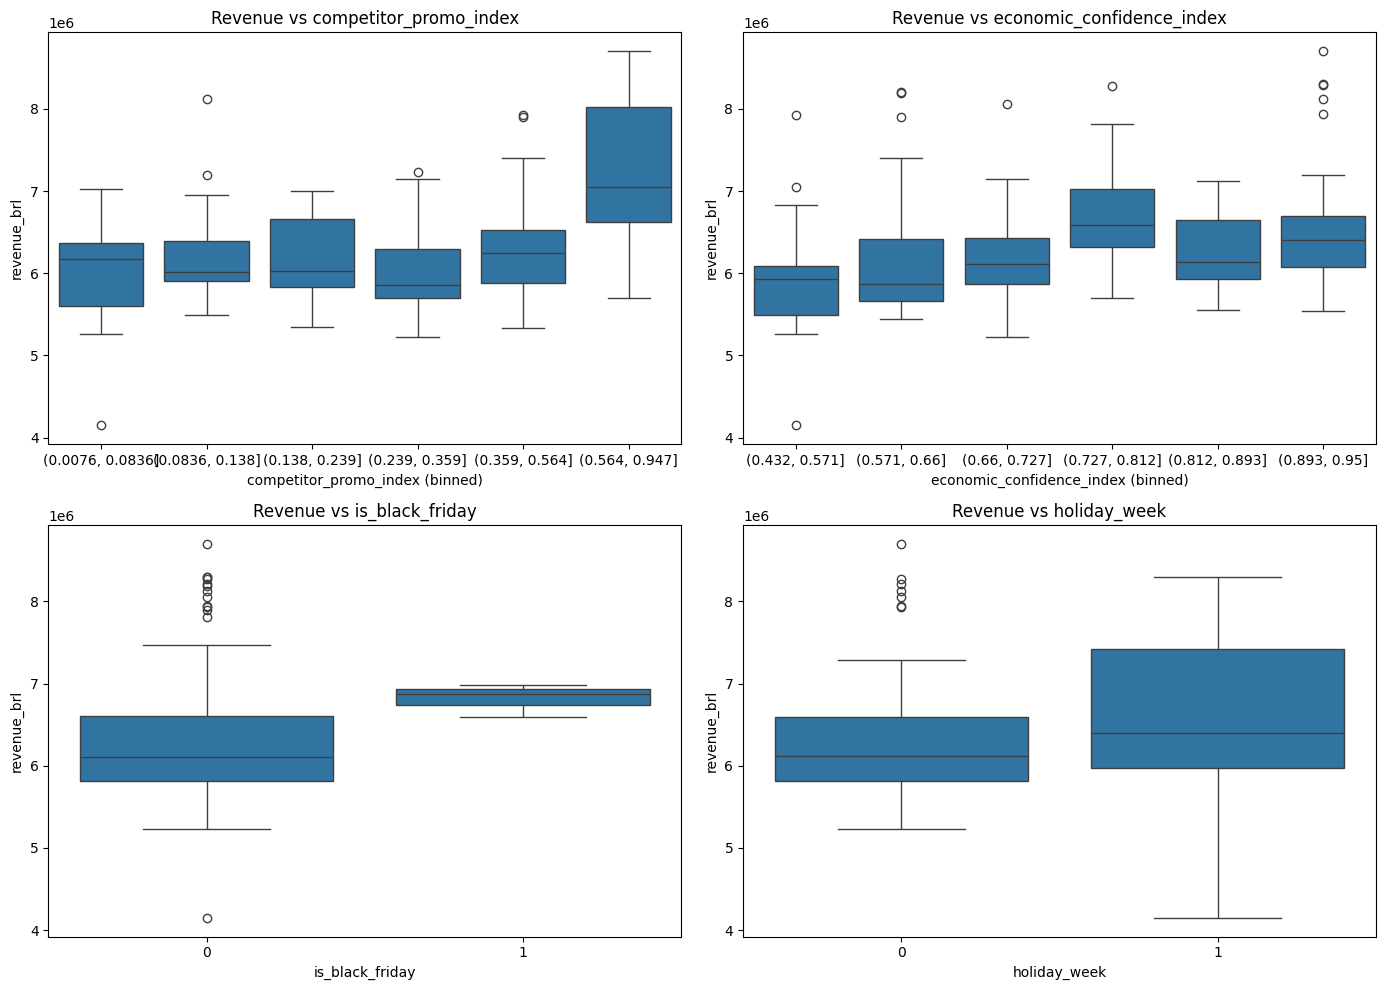

In [16]:

vars_to_plot = [
    "competitor_promo_index",
    "economic_confidence_index",
    "is_black_friday",
    "holiday_week"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, var in enumerate(vars_to_plot):
    ax = axes[i // 2, i % 2]

    if df1[var].nunique() <= 2:
        sns.boxplot(
            data=df1,
            x=var,
            y="revenue_brl",
            ax=ax
        )
    else:
        df1["bin"] = pd.qcut(df1[var], q=6, duplicates="drop")

        sns.boxplot(
            data=df1,
            x="bin",
            y="revenue_brl",
            ax=ax
        )

        ax.set_xlabel(f"{var} (binned)")

    ax.set_title(f"Revenue vs {var}")

plt.tight_layout()
plt.show()

## 2.0 Variable Classification
The selection of variables is based on theoretical reasoning and causal assumptions, rather than model performance metrics. The goal is to ensure unbiased estimation of media effects, even if it comes at the cost of predictive accuracy.

## 2.1 Choosing Target Variable (Units Sold vs. Revenue - BRL)

- Media investment data is reported in BRL, so using Revenue (BRL) as the target variable is more appropriate.
- Estimating Units Sold would introduce additional complexity, as it would require estimating the average price.
- For example, selling 1,000 units at an average price of 10 BRL results in 10,000 BRL in revenue, while selling 100 units at an average price of 100 BRL leads to the same revenue.
- Therefore, revenue provides a more direct and consistent measure aligned with media investments.

## 2.2 Choosing Independent Variables
Reference: https://towardsdatascience.com/marketing-mix-modeling-mmm-how-to-avoid-biased-channel-estimates-f9201fc3e91d/

### 2.2.1 Valid Media Variables
- TV Spend
- Google Search Spend
- Google Display Spend
- Meta Spend
- OOH Spend
- Influencer Spend

### 2.2.2 Control Variables (Confounders)
Important variables, as they affect both revenue and media spend. Excluding them may lead the model to overestimate media effects.
- Competitor Promo Index
- Economic Confidence Index
- Is Black Friday
- Holiday Week

### 2.2.3 Excluded Variables

- units_sold: Excluded because it is co-determined with revenue_brl
through the accounting identity (revenue = units_sold × price).
It is an alternative target variable, not a cause of revenue.

- avg_price_brl: Excluded because revenue = units_sold × price
by definition. Including price as a feature would create a
mechanical relationship with the target, absorbing variance
that should be attributed to media channels and biasing
their estimates.

- leads_generated, website_sessions, and coupons_redeemed: Excluded as mediator (post-treatment) variables, as they are influenced by media spending and would bias the estimated causal effects of media investments.

- affiliate_commission_brl: Excluded as it is a consequence of sales and would introduce target leakage.

- email_crm_sends: Excluded in this modeling cycle to maintain
consistency across media inputs — only paid spend variables
were included. CRM volume is an owned media metric (activity,
not spend), which requires different treatment and ROI
interpretation. It is a candidate for inclusion in a next
modeling iteration.

# 3. EDA (Exploratory Data Analysis)

In [17]:
df2 = df1.copy()

## 3.1 Time-Series Decomposition
References: https://medium.com/fifty-five-data-science/how-to-properly-handle-contextual-effects-trend-seasonality-holidays-in-marketing-mix-modeling-bd3f254d96d5
- https://rhydhamgupta.medium.com/fitting-a-base-trend-capturing-mmm-modelling-919a67adf849
- https://rhydhamgupta.medium.com/transformations-in-mmm-modelling-7fad3e4f8fe5

### 3.1.1 STL
- Upward trend in revenue, suggesting underlying business growth independent of media effects.
- The seasonal component exhibits strong and consistent patterns across years, with significant peaks. This highlights the importance of controlling for seasonality to avoid attributing these effects to media.

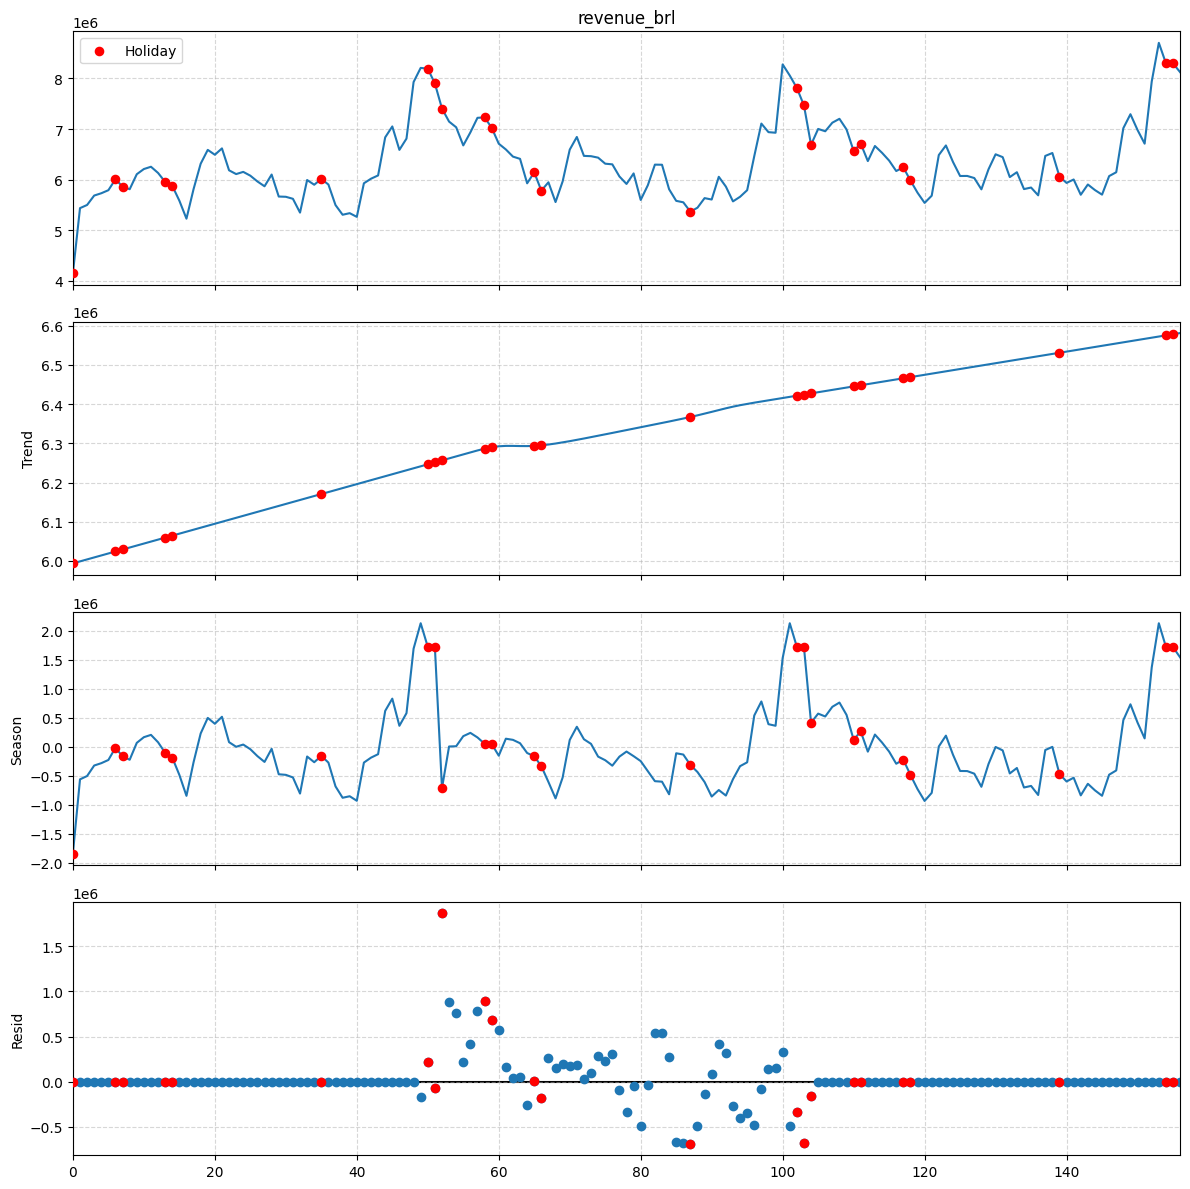

In [18]:
df_ts = df2.copy()

stl = STL(df_ts["revenue_brl"], period=52, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 12)

componentes = [
    stl_result.observed,
    stl_result.trend,
    stl_result.seasonal,
    stl_result.resid
]

mask_holidays = df_ts["holiday_week"] == 1

for i, ax in enumerate(fig.get_axes()):
    x_holidays = df_ts.index[mask_holidays]
    y_holidays = componentes[i][mask_holidays]

    ax.scatter(
        x_holidays,
        y_holidays,
        color='red',
        s=35,
        zorder=5,
        label='Holiday' if i == 0 else ""
    )

    ax.grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 3.1.2 Prophet

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

df_base = df2[[
    "date",
    "revenue_brl",
    "is_black_friday",
    "holiday_week"
]].copy()

df_base = df_base.rename(columns={
    "date": "ds",
    "revenue_brl": "y"
})

df_base["ds"] = pd.to_datetime(df_base["ds"])
df_base = df_base.sort_values("ds").reset_index(drop=True)

In [20]:

baseline_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5
)

baseline_model.add_regressor("is_black_friday")
baseline_model.add_regressor("holiday_week")

baseline_model.fit(df_base)

baseline_forecast = baseline_model.predict(df_base)

In [21]:
baseline_components = baseline_forecast[[
    "ds",
    "trend",
    "yearly",
    "is_black_friday",
    "holiday_week",
    "yhat"
]].copy()

baseline_components["baseline_without_events"] = (
    baseline_components["trend"] +
    baseline_components["yearly"]
)

baseline_components["event_effect"] = (
    baseline_components["is_black_friday"] +
    baseline_components["holiday_week"]
)

baseline_components["baseline_with_events"] = (
    baseline_components["baseline_without_events"] +
    baseline_components["event_effect"]
)

baseline_components.head()

,ds,trend,yearly,is_black_friday,holiday_week,yhat,baseline_without_events,event_effect,baseline_with_events
0,2022-01-03,5275676.98,577766.23,0.00,-163113.94,5690329.27,5853443.22,-163113.94,5690329.27
1,2022-01-10,5322596.07,270926.91,0.00,0.00,5593522.99,5593522.99,0.00,5593522.99
2,2022-01-17,5369515.16,300885.07,0.00,0.00,5670400.23,5670400.23,0.00,5670400.23
3,2022-01-24,5416434.25,480930.03,0.00,0.00,5897364.29,5897364.29,0.00,5897364.29
4,2022-01-31,5463353.34,586173.40,0.00,0.00,6049526.74,6049526.74,0.00,6049526.74


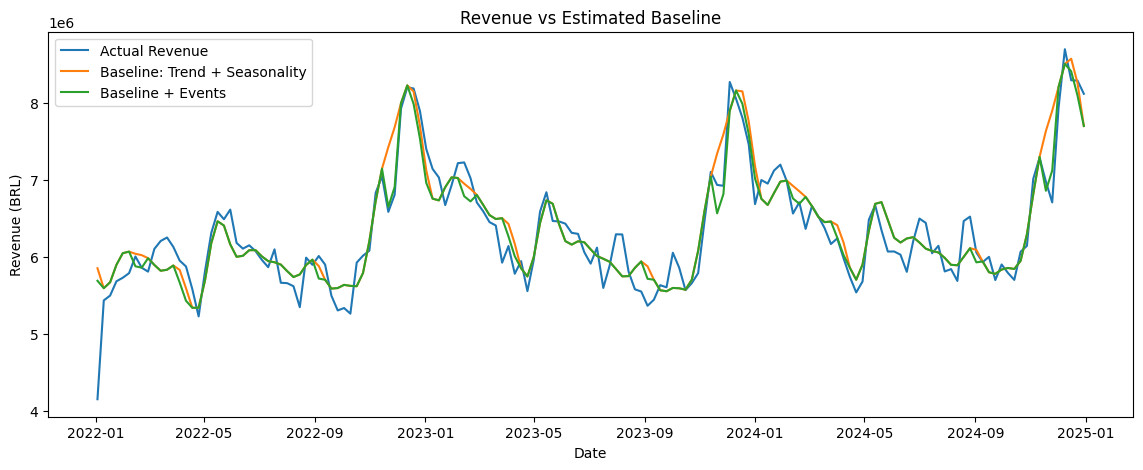

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(df_base["ds"], df_base["y"], label="Actual Revenue")
plt.plot(baseline_components["ds"], baseline_components["baseline_without_events"], label="Baseline: Trend + Seasonality")
plt.plot(baseline_components["ds"], baseline_components["baseline_with_events"], label="Baseline + Events")

plt.title("Revenue vs Estimated Baseline")
plt.xlabel("Date")
plt.ylabel("Revenue (BRL)")
plt.legend()
plt.show()

## 3.2 Media Spend Patterns

### 3.2.1 Flighting and Seasonality
- Google and Meta investments are continuous, with spend present in all weeks.
- TV, OOH, and Influencer channels exhibit clear flighting patterns, with a high proportion of zero-spend weeks (~60%), indicating intermittent campaign activity.
- This behavior is typical of campaign-based channels and requires modeling carryover effects (adstock), as their impact may persist beyond active spend periods.
- TV spend shows a strong concentration at the end of the year, suggesting alignment with major commercial events such as Black Friday and holiday periods.

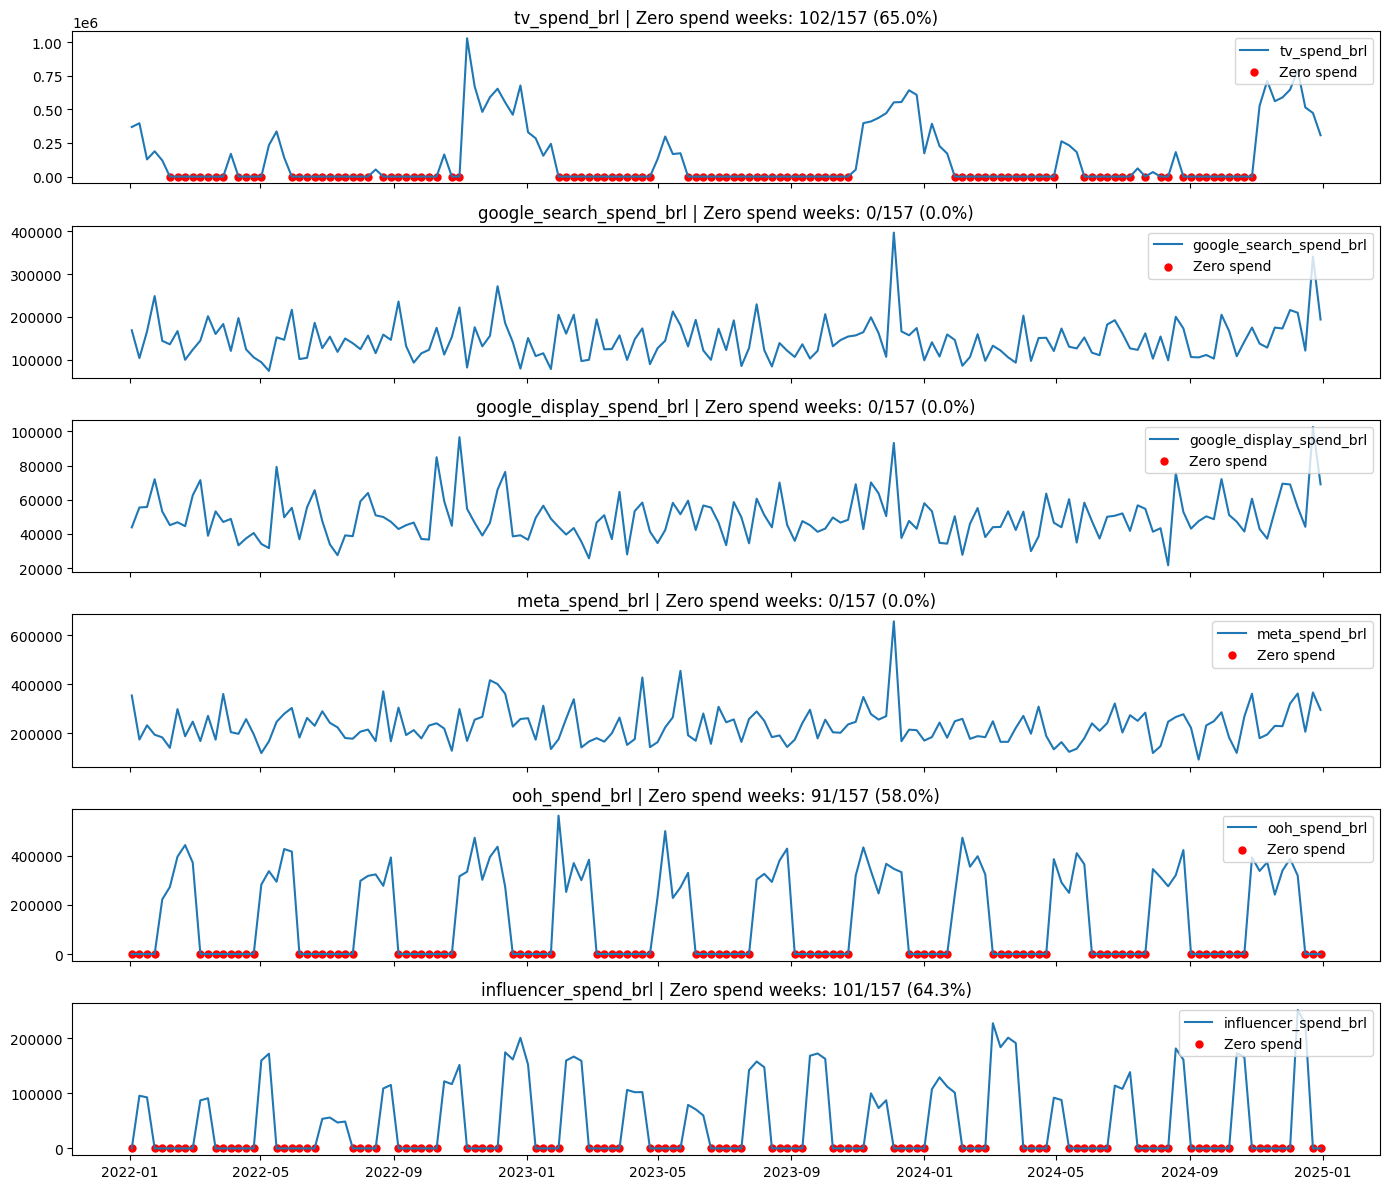

In [23]:
spend_cols = [
    "tv_spend_brl",
    "google_search_spend_brl",
    "google_display_spend_brl",
    "meta_spend_brl",
    "ooh_spend_brl",
    "influencer_spend_brl"
]

df_plot = df2.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])

fig, axes = plt.subplots(len(spend_cols), 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(spend_cols):
    zero_weeks = (df_plot[col] == 0).sum()
    total_weeks = df_plot[col].shape[0]
    zero_pct = zero_weeks / total_weeks * 100

    axes[i].plot(df_plot["date"], df_plot[col], label=col)

    # red dots where spend = 0
    zero_mask = df_plot[col] == 0
    axes[i].scatter(
        df_plot.loc[zero_mask, "date"],
        df_plot.loc[zero_mask, col],
        color="red",
        s=25,
        label="Zero spend"
    )

    axes[i].set_title(
        f"{col} | Zero spend weeks: {zero_weeks}/{total_weeks} ({zero_pct:.1f}%)"
    )
    axes[i].legend(loc="upper right")

plt.tight_layout()
plt.show()

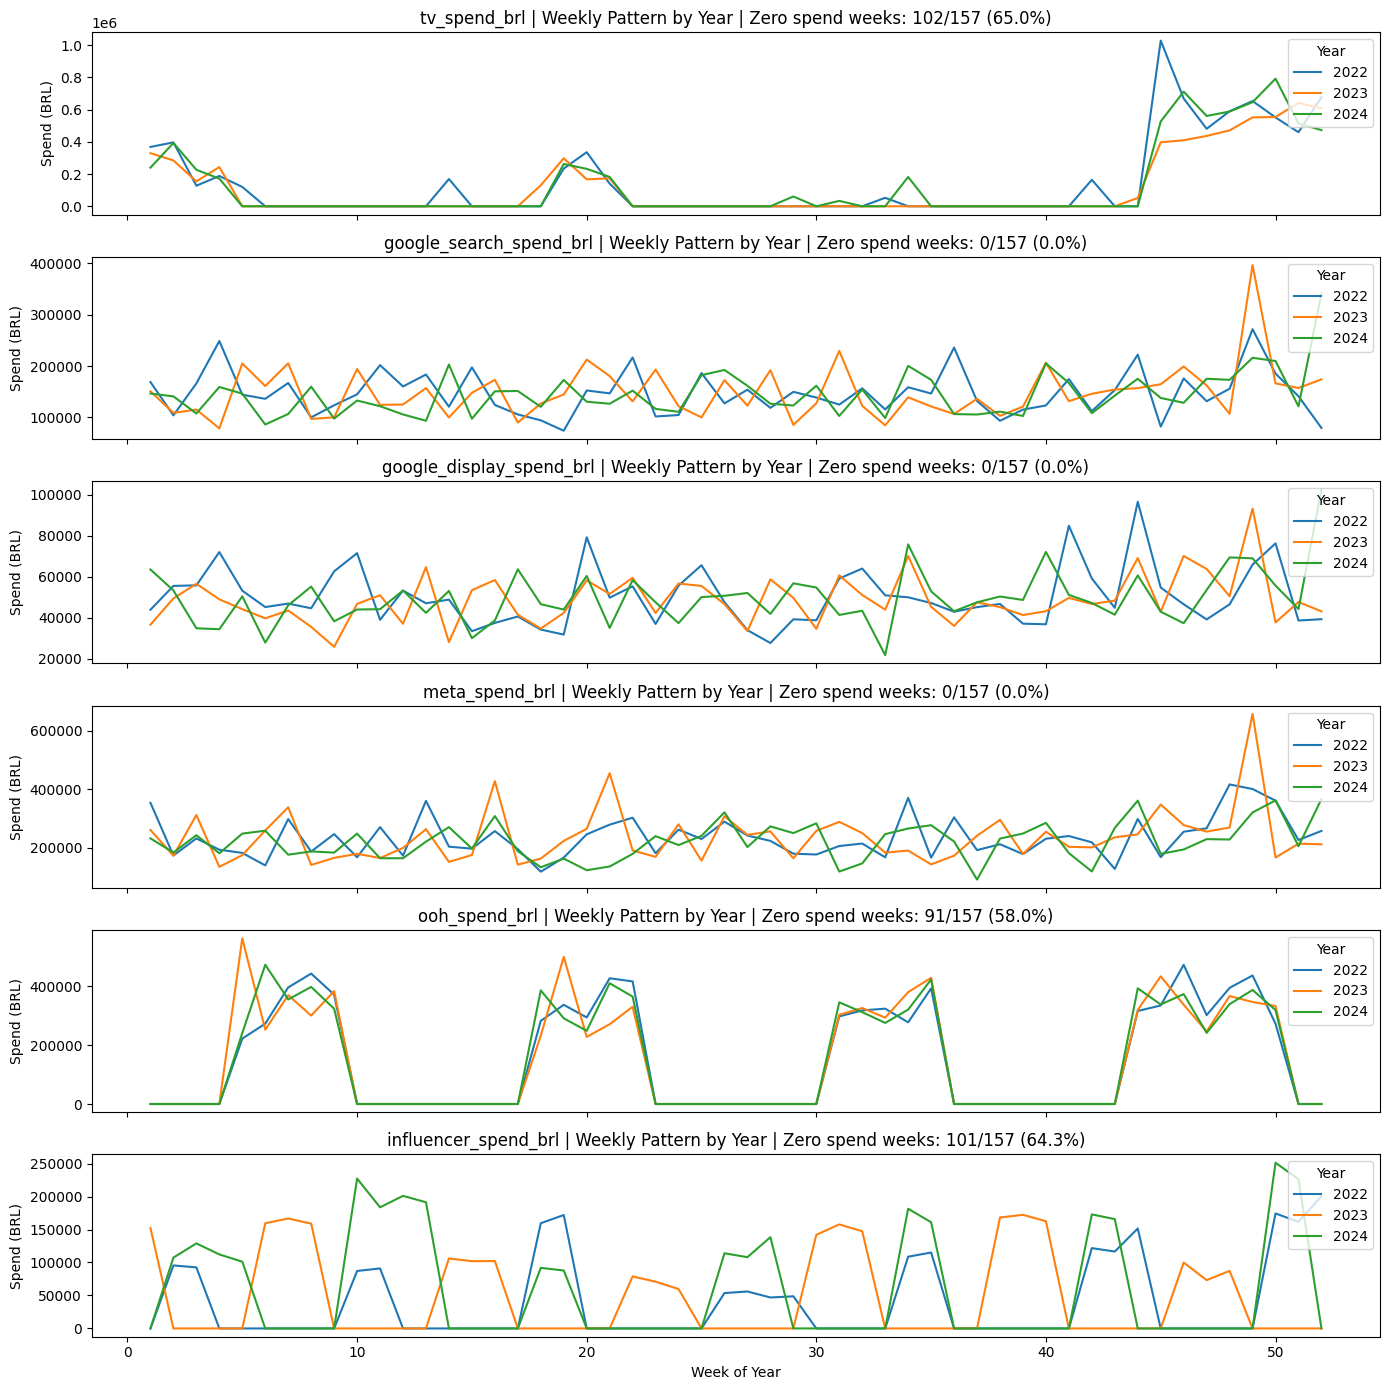

In [24]:

# Copy data
df_plot = df2.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])


# Create time features
df_plot["year"] = df_plot["date"].dt.year
df_plot["week"] = df_plot["date"].dt.isocalendar().week.astype(int)

# Plot weekly patterns by year for each media channel
fig, axes = plt.subplots(len(spend_cols), 1, figsize=(14, 14), sharex=True)

for i, col in enumerate(spend_cols):
    pivot = df_plot.pivot_table(
        index="week",
        columns="year",
        values=col,
        aggfunc="mean"
    )

    pivot.plot(ax=axes[i])

    zero_weeks = (df_plot[col] == 0).sum()
    total_weeks = df_plot[col].shape[0]
    zero_pct = zero_weeks / total_weeks * 100

    axes[i].set_title(
        f"{col} | Weekly Pattern by Year | Zero spend weeks: {zero_weeks}/{total_weeks} ({zero_pct:.1f}%)"
    )
    axes[i].set_xlabel("Week of Year")
    axes[i].set_ylabel("Spend (BRL)")
    axes[i].legend(title="Year", loc="upper right")

plt.tight_layout()
plt.show()

### 3.2.2 Correlation

- Pearson and Spearman correlations show similar patterns, although Spearman coefficients tend to be slightly lower, suggesting that some relationships may be non-linear but still monotonic.

- TV spend shows the highest correlation with revenue. However, this likely reflects shared seasonality (e.g., end-of-year peaks such as Black Friday and holidays) rather than a purely causal media effect.

- Competitor Promo Index is also positively correlated with TV spend and revenue, reinforcing the presence of confounding effects driven by seasonal commercial periods.

- Meta and Google (Search/Display) spend exhibit moderate to high correlations among themselves, indicating potential multicollinearity across digital channels.

- Some channels (e.g., influencer, OOH) show lower or weaker correlations with revenue, which may be explained by flighting patterns and delayed effects (adstock), not captured in simple correlation analysis.

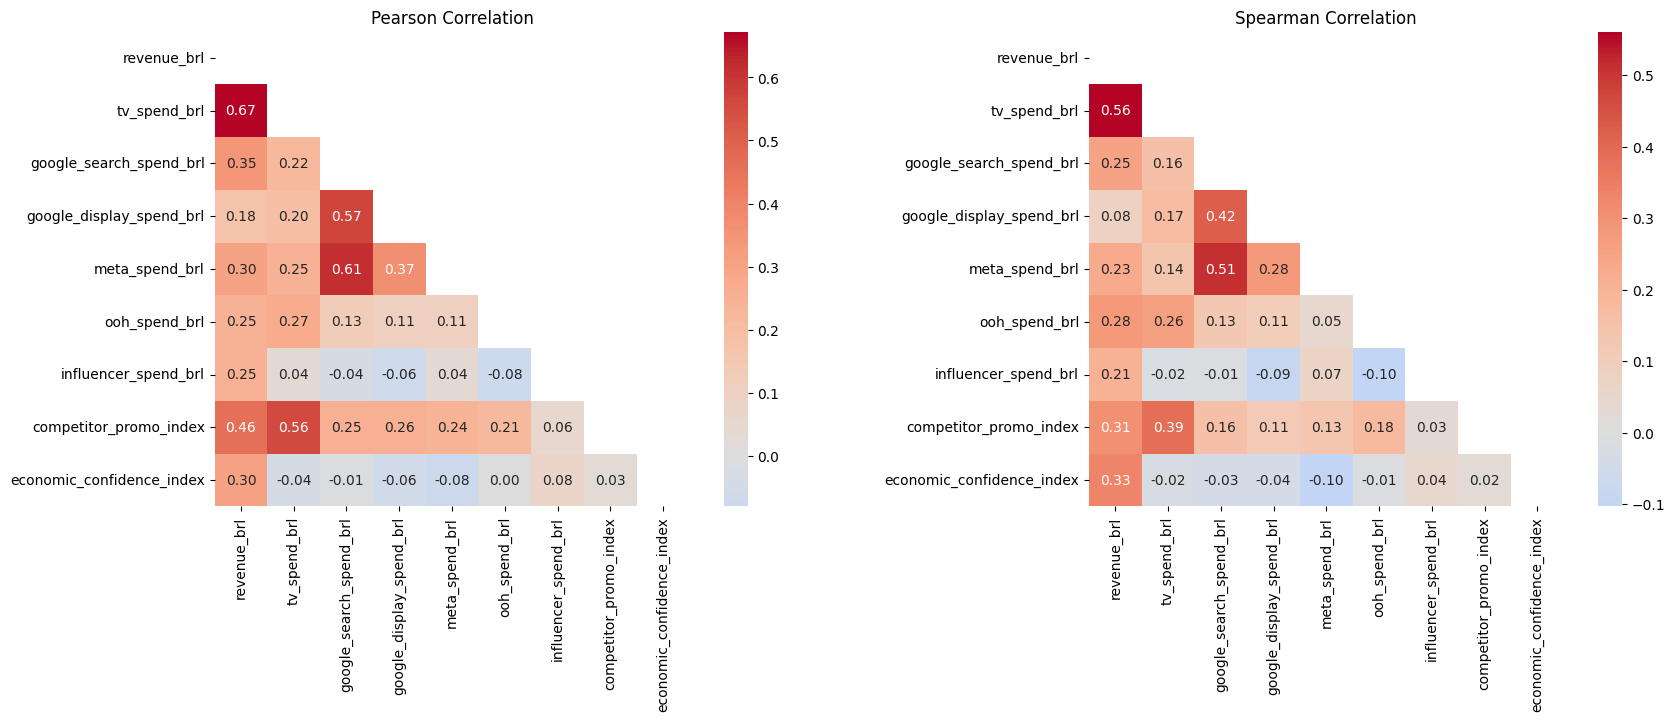

In [25]:
cols = [
    "revenue_brl",
    "tv_spend_brl",
    "google_search_spend_brl",
    "google_display_spend_brl",
    "meta_spend_brl",
    "ooh_spend_brl",
    "influencer_spend_brl",
    "competitor_promo_index",
    "economic_confidence_index"
]

# correlations
corr_pearson = df2[cols].corr(method="pearson")
corr_spearman = df2[cols].corr(method="spearman")

# mask upper triangle
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

# plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axes[0]
)

axes[0].set_title("Pearson Correlation")

sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

### 3.2.3 Multicolinearity VIF Test
References:
- https://towardsdatascience.com/is-multi-collinearity-destroying-your-causal-inferences-in-marketing-mix-modelling-78cb56017c73/
- https://medium.com/@ravitejaa0355/multicollinearity-and-lack-of-variability-in-marketing-mix-models-the-dual-threat-to-accuracy-d870d9916972

- High VIF (> 5 or 10): Indicates multicollinearity. The feature is highly correlated with other variables, making its contribution difficult to isolate.
- Near-Zero VIF: Indicates lack of variability or that the feature is nearly constant, offering little to no useful information for the model.

- Google Search, Display, and Meta show high multicollinearity (high VIF). At this stage, they are kept separate to preserve channel-level granularity, with multicollinearity to be addressed through regularization and adstock transformation.

In [26]:
cols = [
    "tv_spend_brl",
    "google_search_spend_brl",
    "google_display_spend_brl",
    "meta_spend_brl",
    "ooh_spend_brl",
    "influencer_spend_brl",
    "competitor_promo_index",
    "economic_confidence_index"
]

X = df2[cols].copy()

# remove NA se tiver
X = X.dropna()

# calcula VIF
vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)

,variable,VIF
1,google_search_spend_brl,23.19
2,google_display_spend_brl,19.66
3,meta_spend_brl,16.18
7,economic_confidence_index,11.19
6,competitor_promo_index,4.01
0,tv_spend_brl,2.07
4,ooh_spend_brl,1.84
5,influencer_spend_brl,1.50


## 3.3 Causal Identification Challenges

- Strong seasonality (Black Friday and Holiday Weeks) affects both revenue and media investments, creating confounding effects.

- High multicollinearity among digital channels makes it difficult to isolate individual channel contributions.

- Flighting patterns introduce variation but also require modeling carryover effects (adstock).

- Some revenue spikes occur outside observable factors, indicating potential unobserved variables.

These challenges highlight the need for careful modeling choices, including the use of control variables, adstock transformations, and regularization.

# 4. Marketing Mix Modelling
References: https://rhydhamgupta.medium.com/transformations-in-mmm-modelling-7fad3e4f8fe5

In [59]:
df3 = df2.copy()

## 4.1 Adstock Transformation
References:
- https://medium.com/%40amitavamanna/return-on-marketing-investments-using-bayesian-regressadstock-and-hill-function-66ffa3ce1fd1
- https://www.researchgate.net/publication/388175908_The_Role_of_Adstock_and_Saturation_Curves_in_Marketing_Mix_Models_Implications_for_Accuracy_and_Decision-Making?utm_source=chatgpt.com&__cf_chl_tk=ePYMzuI2wgqCtlWgArS.NDWu5jjwpMebR988HrprPBU-1778029535-1.0.1.1-MA9wZHYyjsxZNZVE3Zc3AYCHufC2DQkJ7J4F._UFRNo

- The values for alphas (adstock decay rates) were selected to reflect realistic behaviors in Marketing Mix Modeling (MMM) based on common practices and empirical guidelines from industry literature

Analysis:
- TV spend shows strong seasonality, particularly at the end of the year, with additional activation periods occurring when adstock levels are already low.
- Digital channels (Google Search, Google Display, and Meta) exhibit a more continuous investment pattern, with relatively stable spend levels and occasional peaks.
- OOH presents the strongest flighting behavior, with campaigns being reactivated recurrently after adstock effects decay to lower levels.
- Influencer spend also shows clear flighting patterns, with new investments typically occurring when carryover effects are close to zero.



### 4.1.1 Defining Parameters

In [60]:
media_cols = [
    "tv_spend_brl",
    "google_search_spend_brl",
    "google_display_spend_brl",
    "meta_spend_brl",
    "ooh_spend_brl",
    "influencer_spend_brl"
]

adstock_params = {
    "tv_spend_brl": 0.80,
    "google_search_spend_brl": 0.30,
    "google_display_spend_brl": 0.40,
    "meta_spend_brl": 0.40,
    "ooh_spend_brl": 0.85,
    "influencer_spend_brl": 0.50,
}

df_mmm = df2.copy()

for col in media_cols:
    df_mmm[f"{col}_adstock"] = adstock(
        df_mmm[col],
        alpha=adstock_params[col]
    )

### 4.1.2 Half-Life

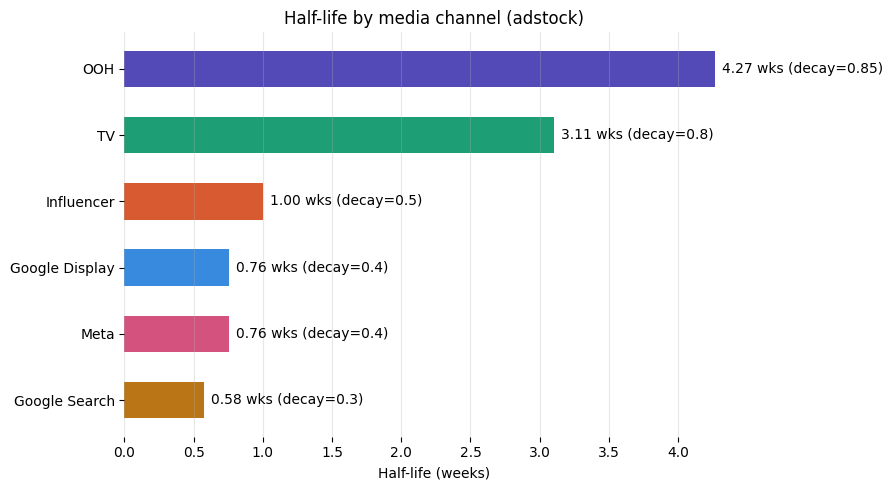

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Channel names and colors
labels_map = {
    "tv_spend_brl": "TV",
    "google_search_spend_brl": "Google Search",
    "google_display_spend_brl": "Google Display",
    "meta_spend_brl": "Meta",
    "ooh_spend_brl": "OOH",
    "influencer_spend_brl": "Influencer",
}

colors = {
    "TV": "#1D9E75",
    "Google Search": "#BA7517",
    "Google Display": "#378ADD",
    "Meta": "#D4537E",
    "OOH": "#534AB7",
    "Influencer": "#D85A30",
}

# Compute half-life from adstock decay
data = sorted(
    [
        (
            labels_map[k],
            v,
            np.log(0.5) / np.log(v)
        )
        for k, v in adstock_params.items()
    ],
    key=lambda x: x[2],
    reverse=True
)

labels, decays, halflives = zip(*data)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    labels,
    halflives,
    color=[colors[l] for l in labels],
    height=0.55
)

# Add labels
for bar, hl, d in zip(bars, halflives, decays):
    ax.text(
        hl + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{hl:.2f} wks (decay={d})",
        va="center",
        fontsize=10
    )

# Styling
ax.set_title("Half-life by media channel (adstock)")
ax.set_xlabel("Half-life (weeks)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

###

### 4.1.3 Media Spend vs Adstock Effect

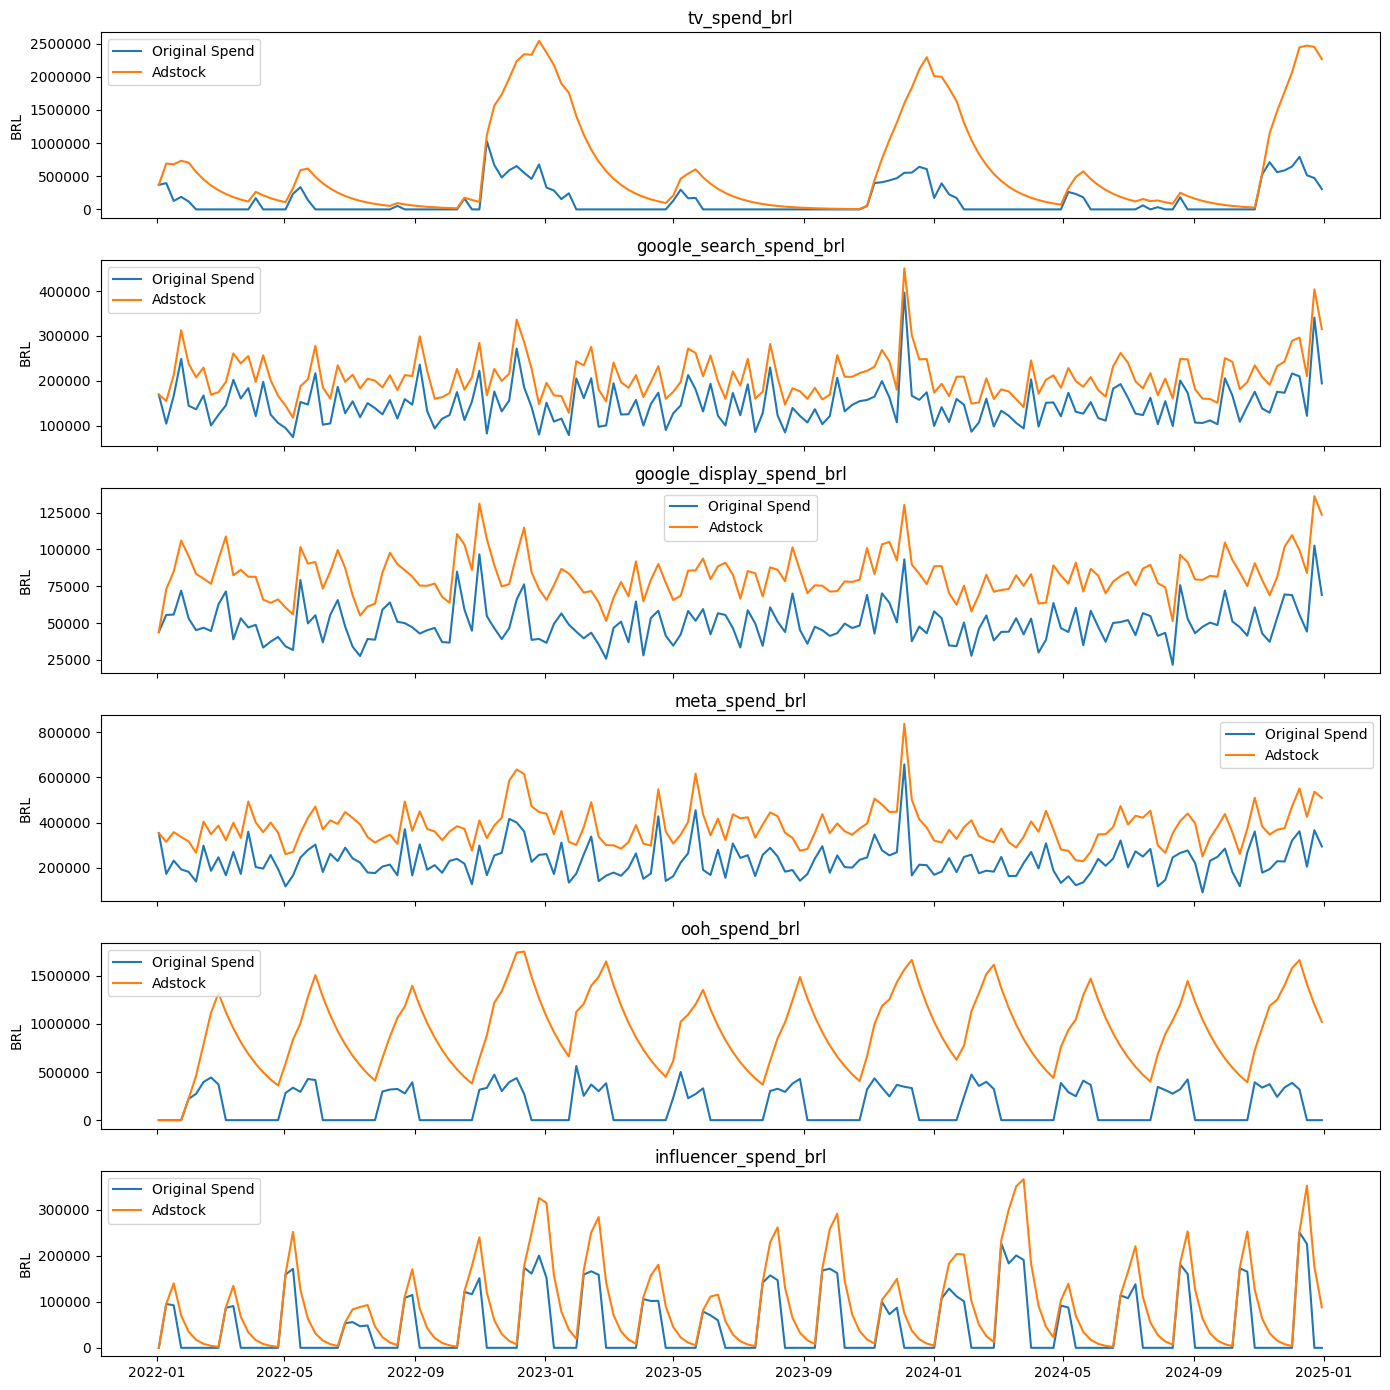

In [62]:
fig, axes = plt.subplots(
    len(media_cols),
    1,
    figsize=(14, 14),
    sharex=True
)

for i, col in enumerate(media_cols):

    axes[i].plot(
        df_mmm["date"],
        df_mmm[col],
        label="Original Spend"
    )

    axes[i].plot(
        df_mmm["date"],
        df_mmm[f"{col}_adstock"],
        label="Adstock"
    )

    # remove scientific notation
    axes[i].yaxis.set_major_formatter(ScalarFormatter())
    axes[i].ticklabel_format(style='plain', axis='y')

    axes[i].set_title(col)
    axes[i].set_ylabel("BRL")

    axes[i].legend()

plt.tight_layout()
plt.show()

## 4.2 Hill Curve
https://www.pymc-labs.com/blog-posts/marketing-mix-modeling-a-complete-guide

### 4.2.1 Defining Parameters

In [63]:
# =========================
# Hill Parameters
# =========================

hill_params = {
    "tv_spend_brl":             {"s": 2.5},
    "google_search_spend_brl":  {"s": 1.2},
    "google_display_spend_brl": {"s": 1.3},
    "meta_spend_brl":           {"s": 1.4},
    "ooh_spend_brl":            {"s": 2.0},
    "influencer_spend_brl":     {"s": 1.8},
}

# =========================
# Apply Hill Transformation
# =========================

for col in media_cols:

    adstock_col = f"{col}_adstock"

    # saturation midpoint
    k = df_mmm[adstock_col].median()

    # hill shape
    s = hill_params[col]["s"]

    # apply hill
    df_mmm[f"{col}_hill"] = hill_function(
        df_mmm[adstock_col],
        k=k,
        s=s
    )

### 4.2.2 Hill Saturation Curves by Channel

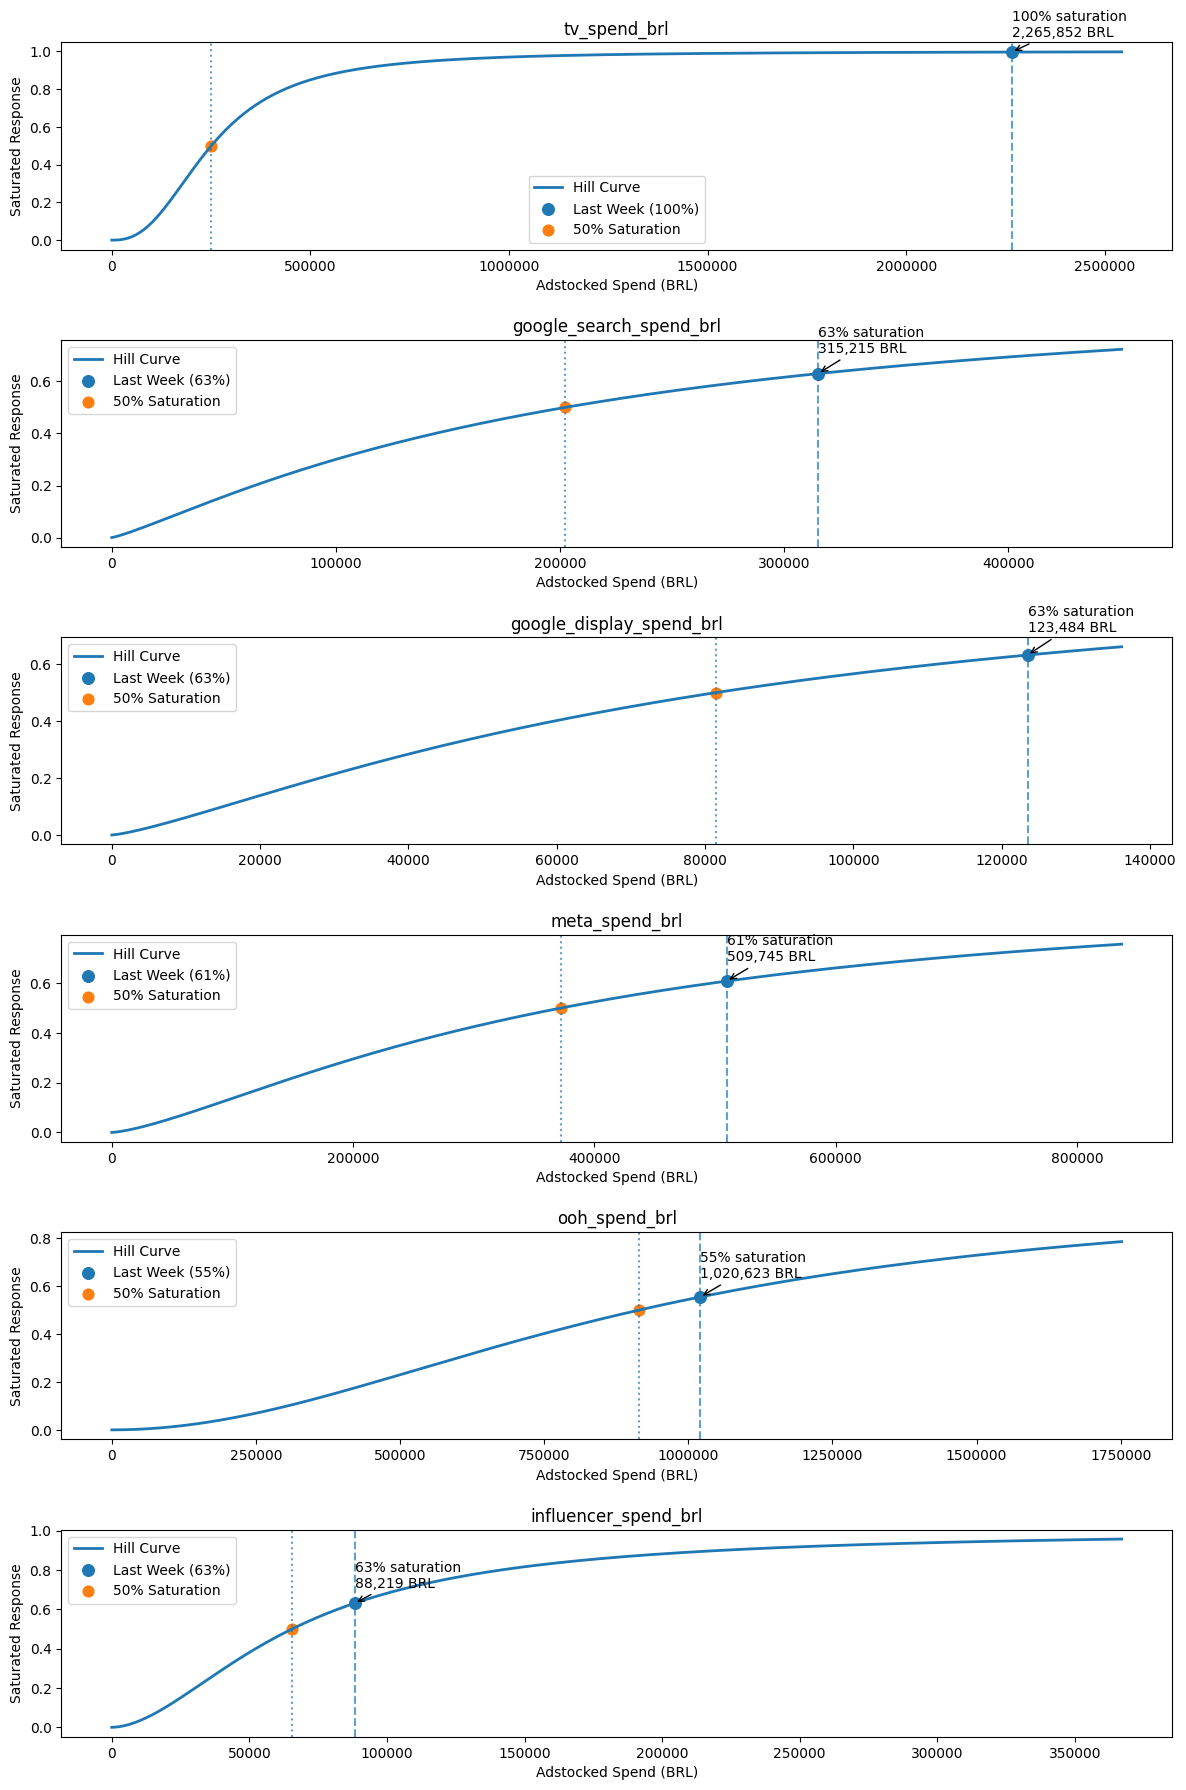

In [64]:
fig, axes = plt.subplots(len(media_cols), 1, figsize=(12, 18))

for i, col in enumerate(media_cols):

    adstock_col = f"{col}_adstock"

    k = df_mmm[adstock_col].median()
    s = hill_params[col]["s"]

    # Hill curve
    x = np.linspace(0, df_mmm[adstock_col].max(), 500)
    y = hill_function(x, k=k, s=s)

    # Last week point
    current_spend = df_mmm[adstock_col].iloc[-1]
    current_response = hill_function(current_spend, k=k, s=s)
    current_pct = current_response * 100

    # Saturation midpoint
    saturation_x = k
    saturation_y = hill_function(k, k=k, s=s)

    # Plot curve
    axes[i].plot(
        x,
        y,
        linewidth=2,
        label="Hill Curve"
    )

    # Current point
    axes[i].scatter(
        current_spend,
        current_response,
        s=70,
        label=f"Last Week ({current_pct:.0f}%)"
    )

    axes[i].axvline(
        current_spend,
        linestyle="--",
        alpha=0.7
    )

    # Saturation midpoint
    axes[i].scatter(
        saturation_x,
        saturation_y,
        s=60,
        label="50% Saturation"
    )

    axes[i].axvline(
        saturation_x,
        linestyle=":",
        alpha=0.7
    )

    # Annotation
    axes[i].annotate(
        f"{current_pct:.0f}% saturation\n{current_spend:,.0f} BRL",
        xy=(current_spend, current_response),
        xytext=(current_spend, current_response + 0.08),
        arrowprops=dict(arrowstyle="->")
    )

    # Remove scientific notation
    axes[i].xaxis.set_major_formatter(ScalarFormatter())
    axes[i].ticklabel_format(style='plain', axis='x')

    axes[i].set_title(col)
    axes[i].set_xlabel("Adstocked Spend (BRL)")
    axes[i].set_ylabel("Saturated Response")

    axes[i].legend()

plt.tight_layout()
plt.show()

## 4.3 Modelling

### 4.3.1 Trend + Seasonality

In [65]:
# Prophet will be fit inside each CV fold to avoid data leakage.
# After CV, it will be refit on the full dataset for the final model.
# trend and yearly are initialized as placeholders for the feature matrix.

df_mmm["trend"]  = 0.0
df_mmm["yearly"] = 0.0

In [66]:
# from prophet import Prophet

# prophet_df = df2[["date", "revenue_brl", "is_black_friday", "holiday_week"]].copy()

# prophet_df.columns = ["ds", "y", "is_black_friday", "holiday_week"]

# model = Prophet(
#     yearly_seasonality=True,
#     weekly_seasonality=False,
#     daily_seasonality=False,
#     changepoint_prior_scale=0.05,
#     seasonality_prior_scale=5
# )

# model.add_regressor("is_black_friday")
# model.add_regressor("holiday_week")

# model.fit(prophet_df)

# forecast = model.predict(prophet_df)

# df_mmm["trend"]  = forecast["trend"].values
# df_mmm["yearly"] = forecast["yearly"].values

### 4.3.2 Features

In [67]:
media_features = [f"{col}_hill" for col in media_cols]

control_features = [
    "trend",
    "yearly",
    "competitor_promo_index",
    "economic_confidence_index",
    "is_black_friday",
    "holiday_week"
]

X = df_mmm[media_features + control_features]
y = df_mmm["revenue_brl"]

### 4.3.3 Models

In [68]:
# forcing coefficients to be positive — media spend cannot have negative impact on revenue
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression(positive=True))
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10, positive=True))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, positive=True, max_iter=10000))
    ])
}

### 4.3.4 Time-Series CV

In [69]:
N_SPLITS  = 4
TEST_SIZE = 13
GAP       = 0

tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, gap=GAP)

cv_results = []
fold_predictions = {name: {} for name in models}

for name, model in models.items():
    fold_metrics = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

        # refit Prophet using only training data to avoid data leakage
        prophet_train = df_mmm[["date", "revenue_brl"]].iloc[train_idx].rename(
            columns={"date": "ds", "revenue_brl": "y"}
        )

        prophet_fold = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False
        )
        prophet_fold.fit(prophet_train)

        # predict trend and yearly for both train and test periods
        all_idx = np.concatenate([train_idx, test_idx])
        future = df_mmm[["date"]].iloc[all_idx].rename(columns={"date": "ds"})
        forecast_fold = prophet_fold.predict(future)

        # inject fold-specific trend and yearly into features
        X_fold = X.copy()
        X_fold.loc[df_mmm.index[all_idx], "trend"]  = forecast_fold["trend"].values
        X_fold.loc[df_mmm.index[all_idx], "yearly"] = forecast_fold["yearly"].values

        X_train, X_test = X_fold.iloc[train_idx], X_fold.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_predictions[name][fold] = {
            "test_idx": test_idx,
            "y_test":   y_test.values,
            "y_pred":   y_pred,
        }

        fold_metrics.append({
            "fold": fold,
            "r2":   r2_score(y_test, y_pred),
            "mae":  mean_absolute_error(y_test, y_pred),
            "mape": mean_absolute_percentage_error(y_test, y_pred) * 100,
            "wape": np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100,
        })

    fold_df = pd.DataFrame(fold_metrics)

    cv_results.append({
        "Model":      name,
        "R2 médio":   fold_df["r2"].mean(),
        "R2 std":     fold_df["r2"].std(),
        "MAE médio":  fold_df["mae"].mean(),
        "MAE std":    fold_df["mae"].std(),
        "MAPE médio": fold_df["mape"].mean(),
        "MAPE std":   fold_df["mape"].std(),
        "WAPE médio": fold_df["wape"].mean(),
        "WAPE std":   fold_df["wape"].std(),
    })

cv_summary = pd.DataFrame(cv_results).round(4)
print(cv_summary.to_string(index=False))

# after CV, refit Prophet on full dataset for final model
prophet_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_full.fit(
    df_mmm[["date", "revenue_brl"]].rename(columns={"date": "ds", "revenue_brl": "y"})
)
forecast_full = prophet_full.predict(
    df_mmm[["date"]].rename(columns={"date": "ds"})
)

df_mmm["trend"]  = forecast_full["trend"].values
df_mmm["yearly"] = forecast_full["yearly"].values

# update X with full-dataset Prophet components for final model
X["trend"]  = df_mmm["trend"].values
X["yearly"] = df_mmm["yearly"].values

     Model  R2 médio  R2 std  MAE médio  MAE std  MAPE médio  MAPE std  WAPE médio  WAPE std
    Linear      0.23    0.78  275720.51 97531.11        4.19      1.44        4.24      1.46
     Ridge      0.32    0.52  273069.68 82766.13        4.12      1.01        4.18      1.07
ElasticNet      0.30    0.60  273056.75 88148.29        4.13      1.16        4.18      1.20


/tmp/ipykernel_1895/4043246951.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["trend"]  = df_mmm["trend"].values
/tmp/ipykernel_1895/4043246951.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["yearly"] = df_mmm["yearly"].values


### 4.3.5 Plot Folds Results

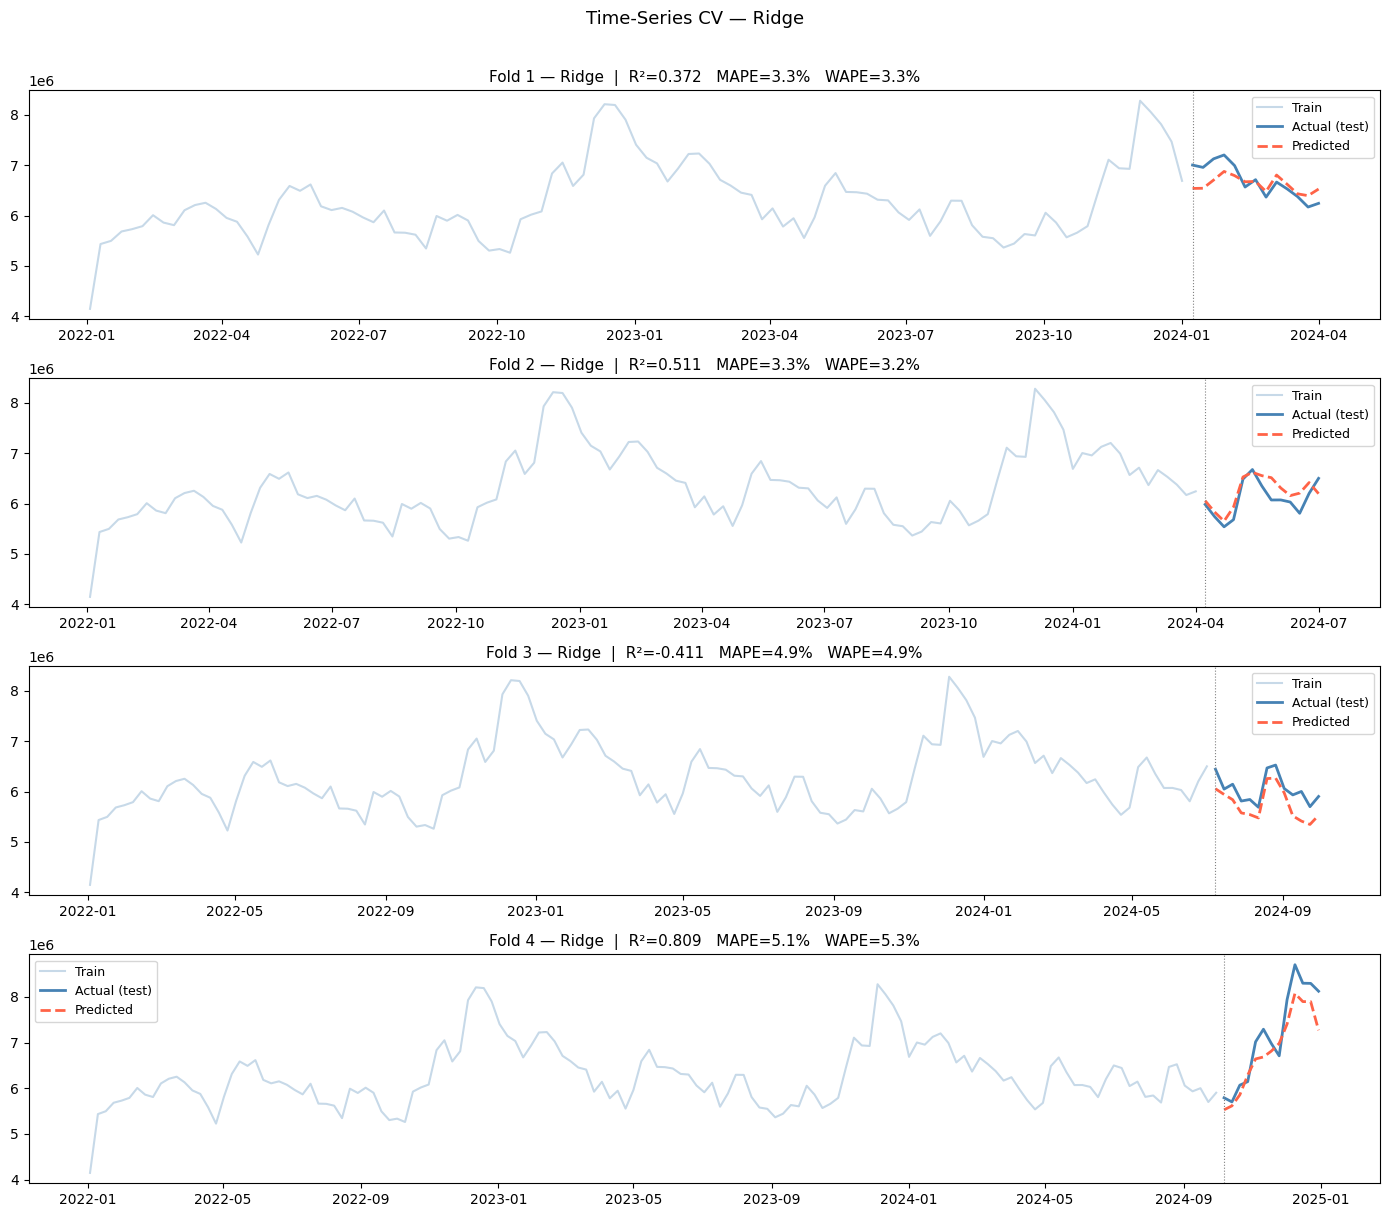

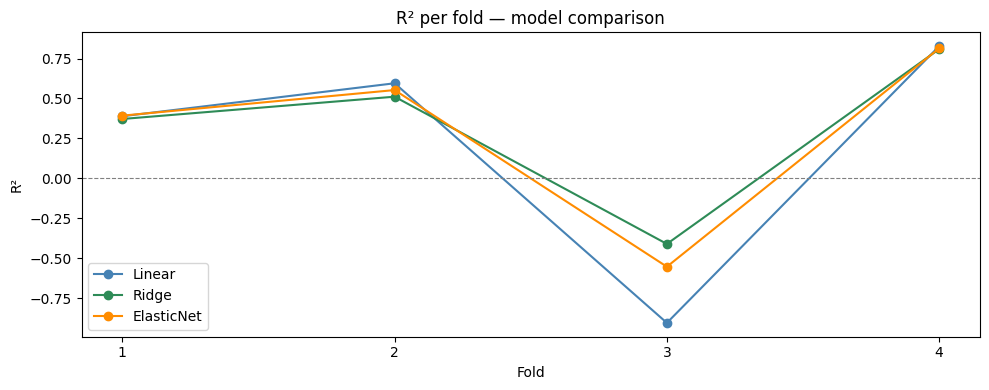

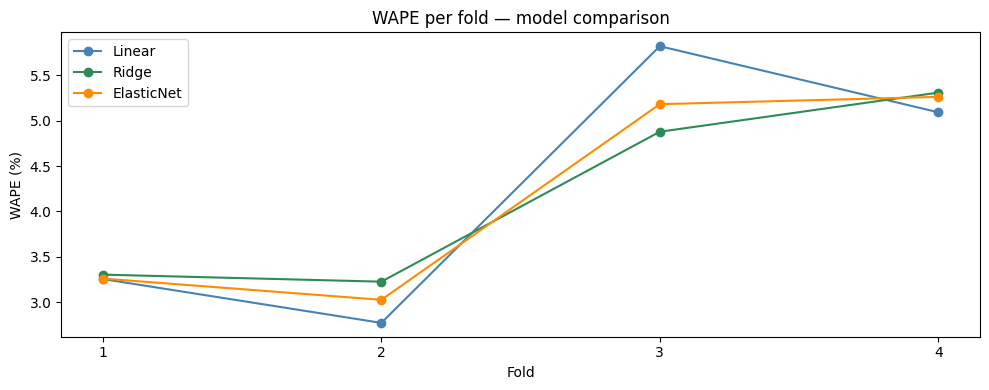

In [70]:
best_model_name = cv_summary.loc[cv_summary["WAPE médio"].idxmin(), "Model"]
best_model = models[best_model_name]

fig, axes = plt.subplots(N_SPLITS, 1, figsize=(14, N_SPLITS * 3), sharex=False)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    ax = axes[fold - 1]

    # refit Prophet for this fold
    prophet_train = df_mmm[["date", "revenue_brl"]].iloc[train_idx].rename(
        columns={"date": "ds", "revenue_brl": "y"}
    )
    prophet_fold = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    prophet_fold.fit(prophet_train)

    all_idx = np.concatenate([train_idx, test_idx])
    future = df_mmm[["date"]].iloc[all_idx].rename(columns={"date": "ds"})
    forecast_fold = prophet_fold.predict(future)

    X_fold = X.copy()
    X_fold.loc[df_mmm.index[all_idx], "trend"]  = forecast_fold["trend"].values
    X_fold.loc[df_mmm.index[all_idx], "yearly"] = forecast_fold["yearly"].values

    X_train, X_test = X_fold.iloc[train_idx], X_fold.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_train     = df_mmm["date"].iloc[train_idx]
    dates_test      = df_mmm["date"].iloc[test_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

    ax.plot(dates_train, y_train, color="steelblue", alpha=0.3, label="Train")
    ax.plot(dates_test,  y_test,  color="steelblue", linewidth=2, label="Actual (test)")
    ax.plot(dates_test,  y_pred,  color="tomato", linestyle="--", linewidth=2, label="Predicted")
    ax.axvline(dates_test.iloc[0], color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(
        f"Fold {fold} — {best_model_name}  |  R²={r2:.3f}   MAPE={mape:.1f}%   WAPE={wape:.1f}%",
        fontsize=11
    )
    ax.legend(fontsize=9)

plt.suptitle(f"Time-Series CV — {best_model_name}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# R² per fold — all models
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"Linear": "steelblue", "Ridge": "seagreen", "ElasticNet": "darkorange"}
folds  = range(1, N_SPLITS + 1)

for name in models:
    r2_per_fold = [
        r2_score(
            fold_predictions[name][f]["y_test"],
            fold_predictions[name][f]["y_pred"]
        )
        for f in folds
    ]
    ax.plot(folds, r2_per_fold, marker="o", label=name, color=colors[name])

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(list(folds))
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("R² per fold — model comparison")
ax.legend()
plt.tight_layout()
plt.show()

# WAPE per fold — all models
fig, ax = plt.subplots(figsize=(10, 4))

for name in models:
    wape_per_fold = [
        np.sum(np.abs(fold_predictions[name][f]["y_test"] - fold_predictions[name][f]["y_pred"]))
        / np.sum(np.abs(fold_predictions[name][f]["y_test"])) * 100
        for f in folds
    ]
    ax.plot(folds, wape_per_fold, marker="o", label=name, color=colors[name])

ax.set_xticks(list(folds))
ax.set_xlabel("Fold")
ax.set_ylabel("WAPE (%)")
ax.set_title("WAPE per fold — model comparison")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3.6 MMM Comparative Analysis: Linear, Ridge & ElasticNet



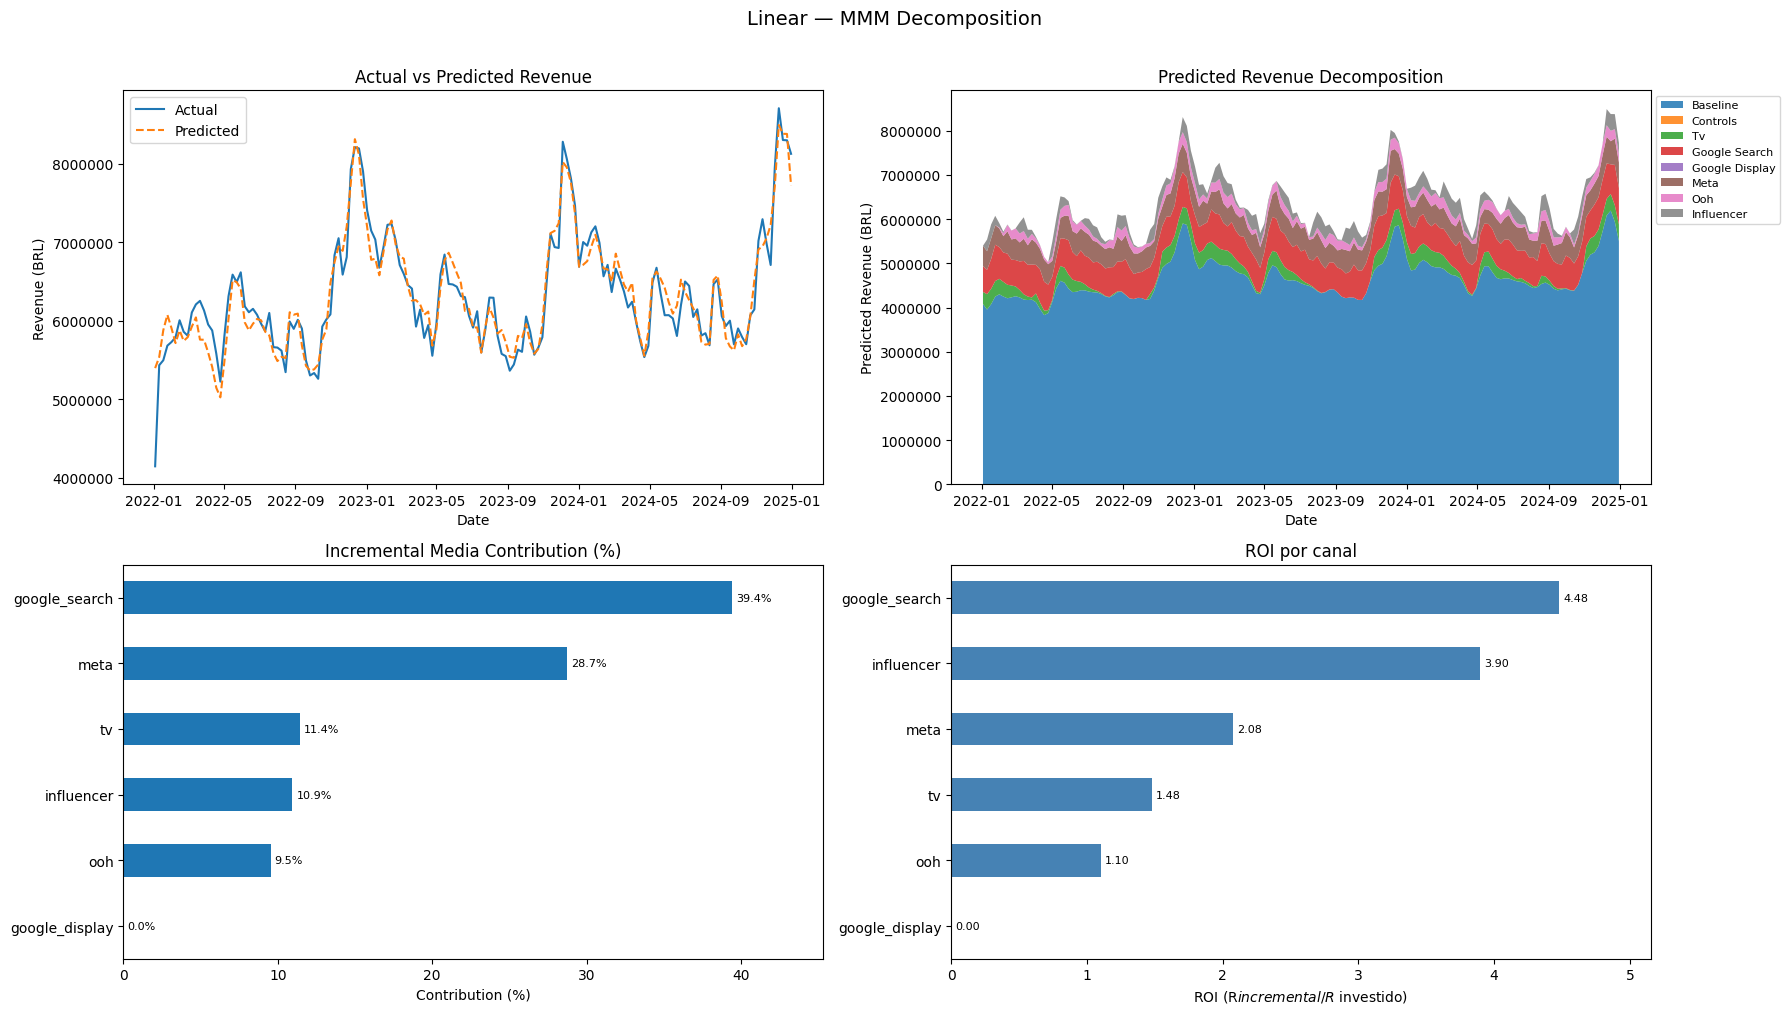

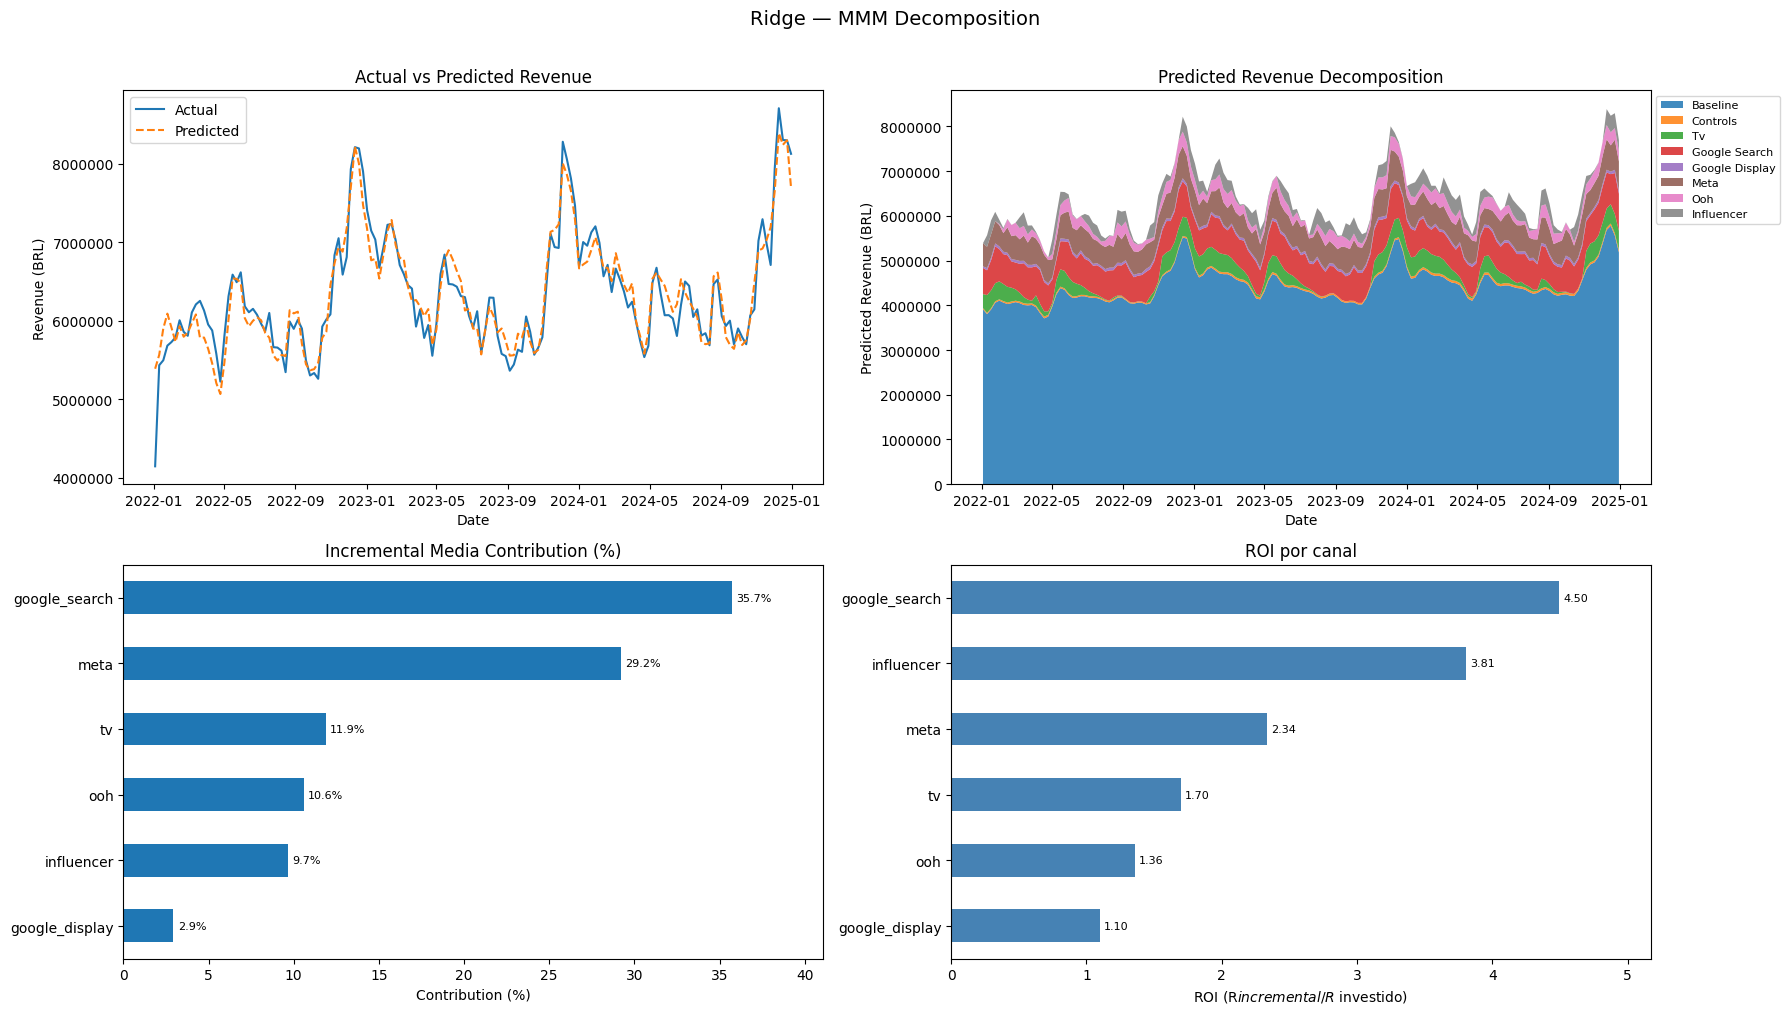

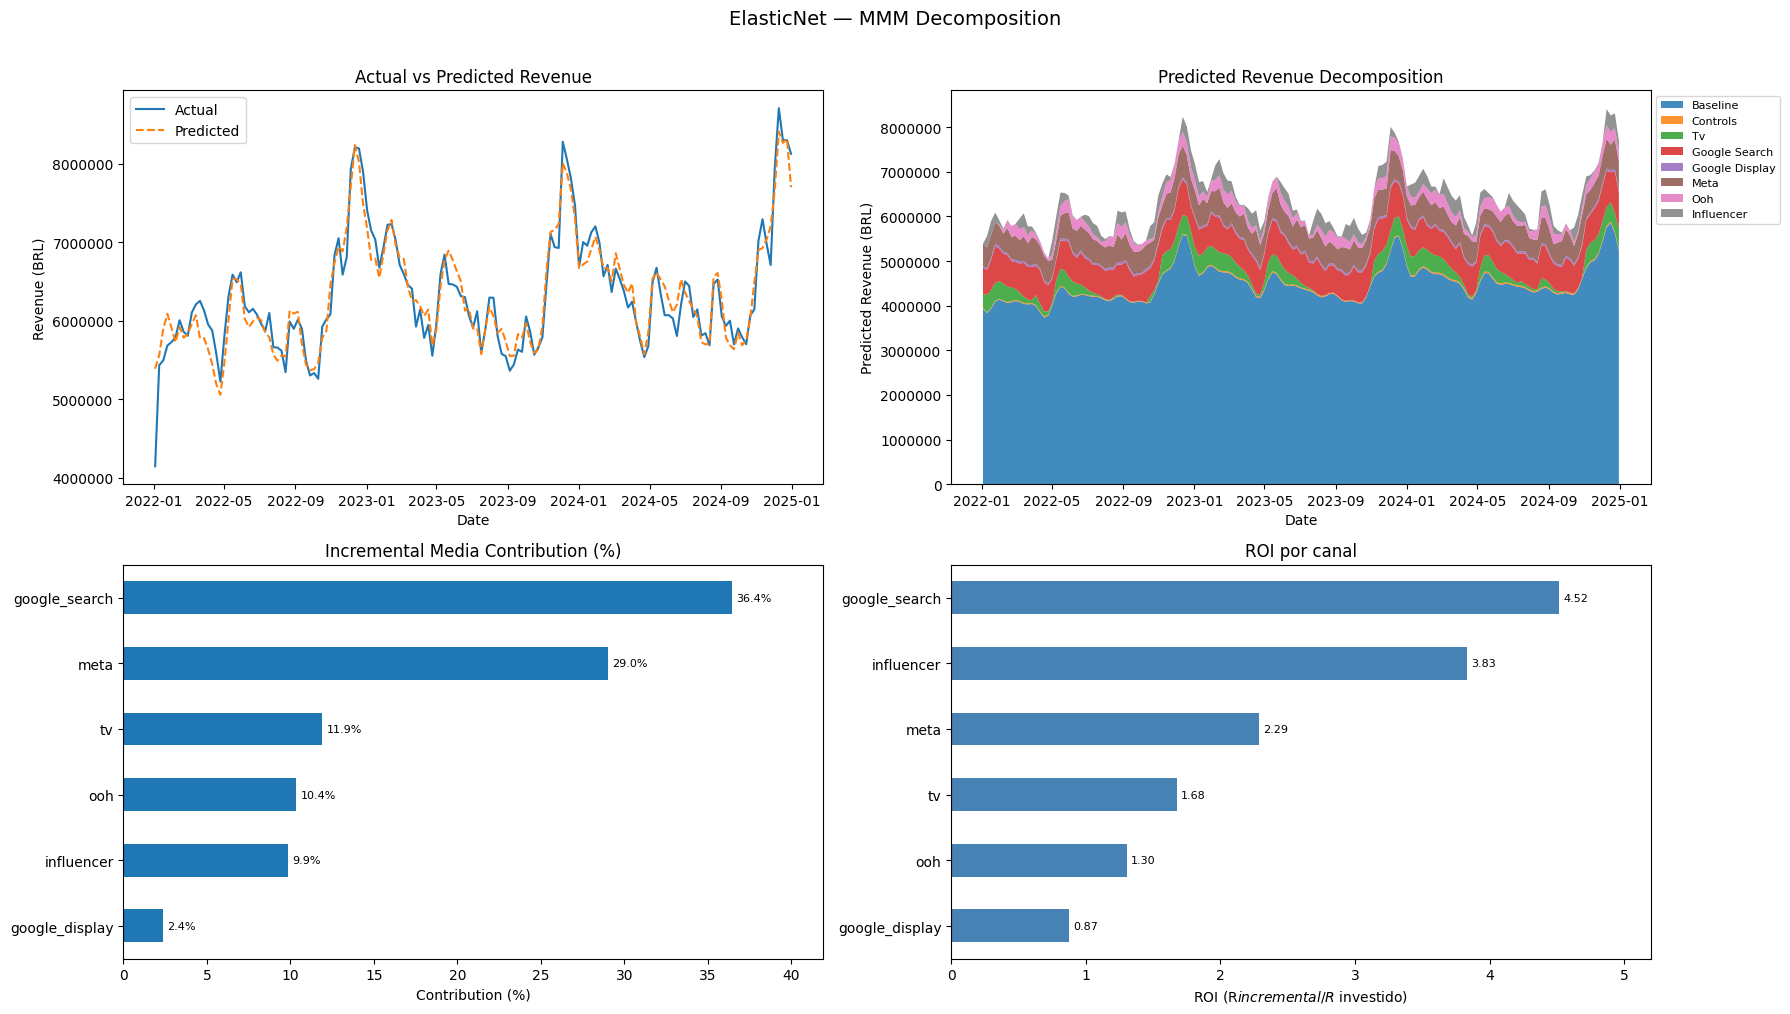

,Linear,Ridge,ElasticNet
google_search,4.48,4.50,4.52
influencer,3.90,3.81,3.83
meta,2.08,2.34,2.29
tv,1.48,1.70,1.68
ooh,1.10,1.36,1.30
google_display,0.00,1.10,0.87


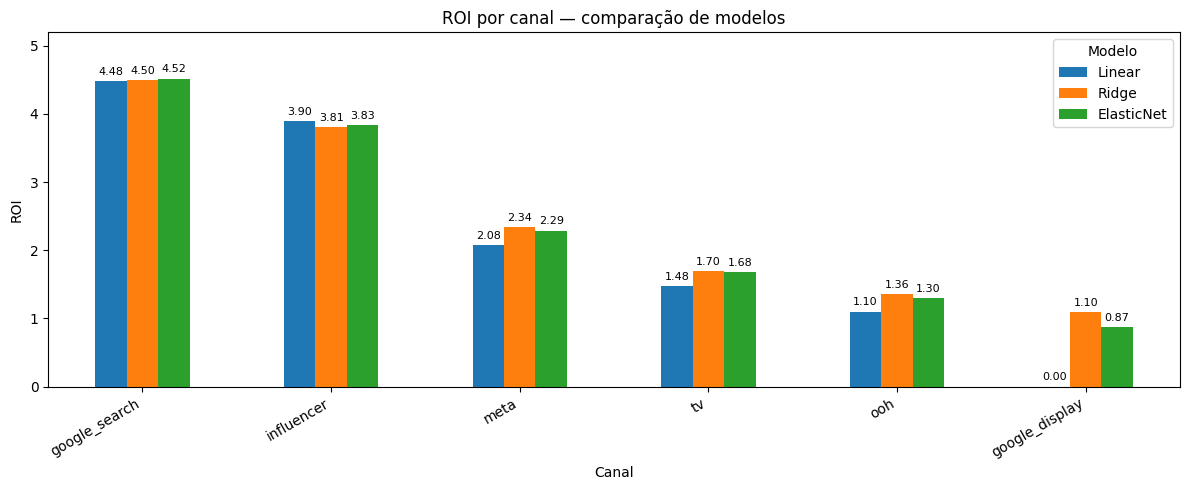

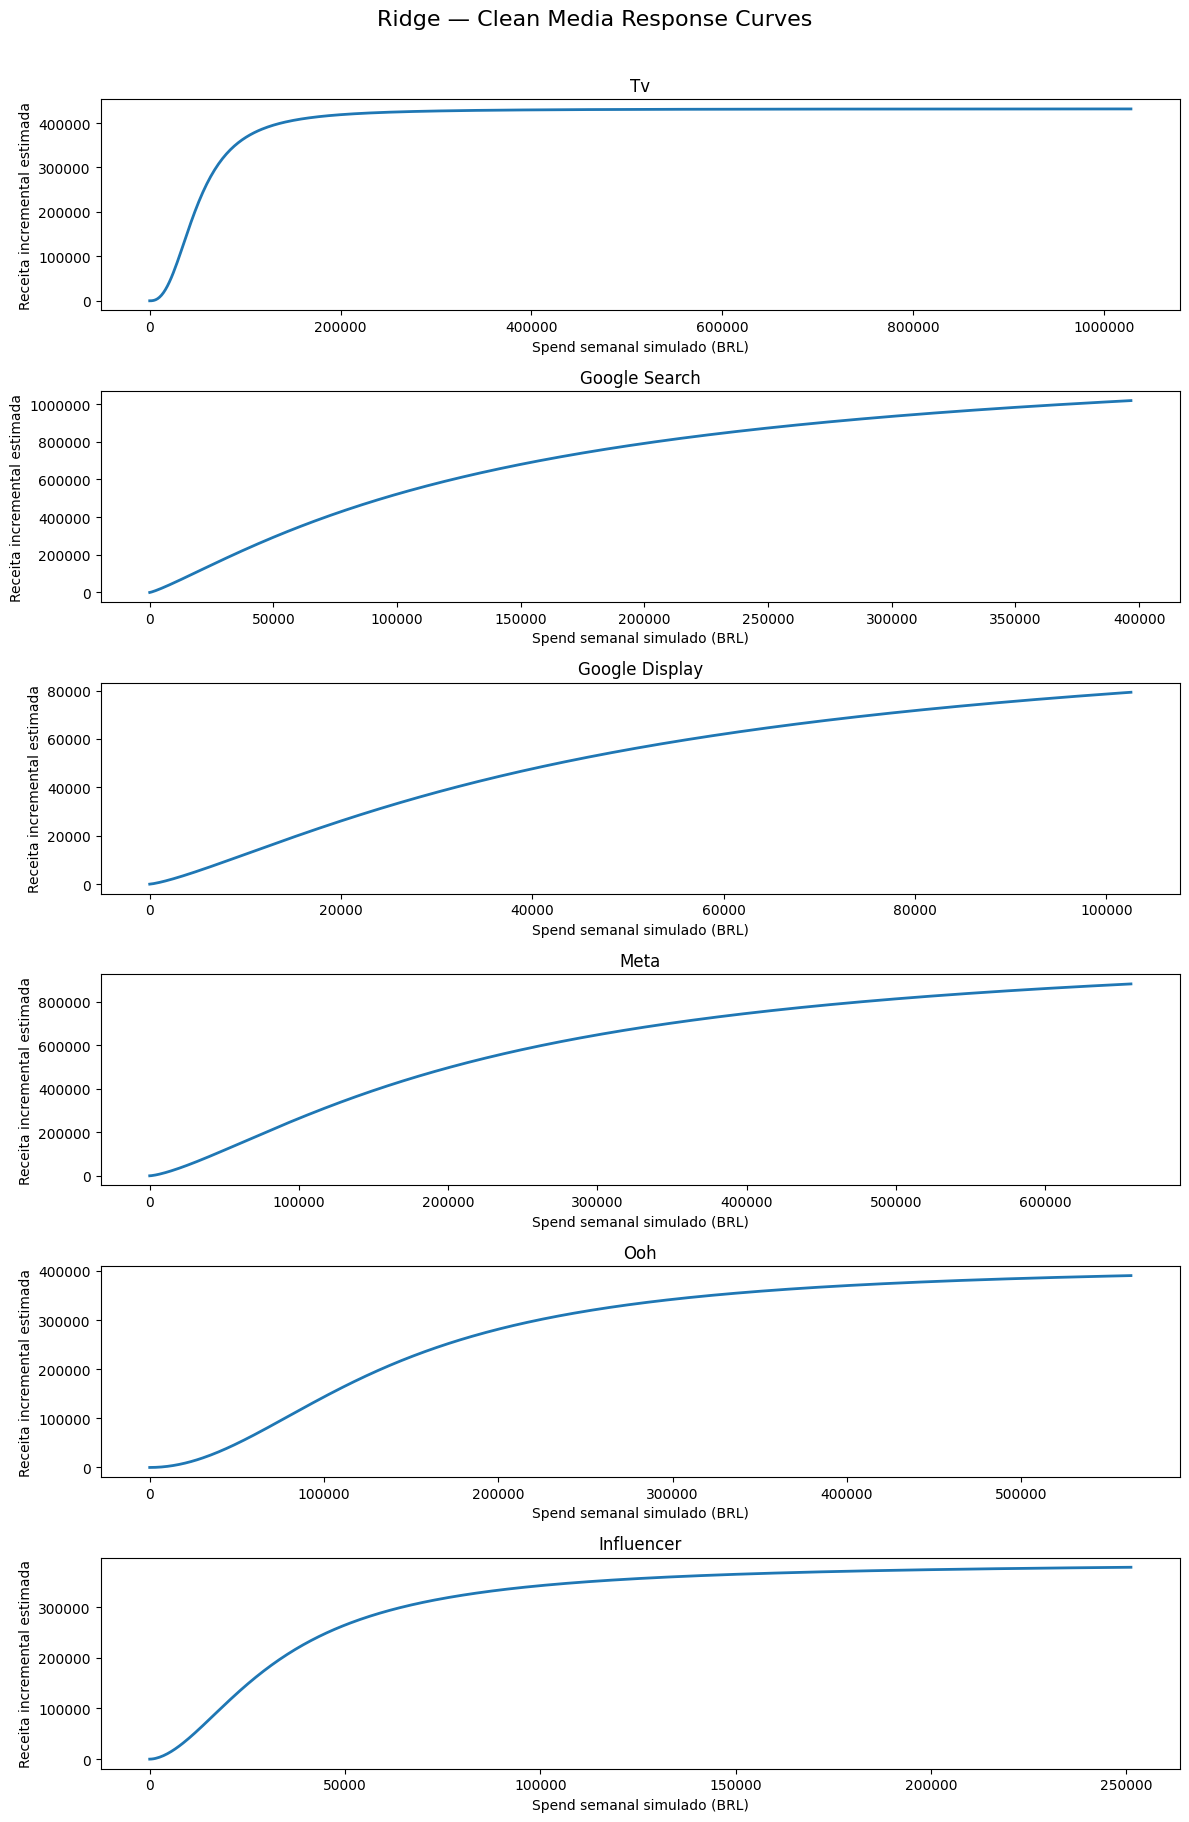

In [71]:
# para CV (com scaler embutido, recebe X bruto)
pipelines = {
    "Linear":     Pipeline([("scaler", StandardScaler()), ("model", LinearRegression(positive=True))]),
    "Ridge":      Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10, positive=True))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, positive=True, max_iter=10000))]),
}

# para decomposição (sem scaler, recebe X_scaled)
models = {
    "Linear":     LinearRegression(positive=True),
    "Ridge":      Ridge(alpha=10, positive=True),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, positive=True, max_iter=10000),
}

scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

all_results = {}

for name, model in models.items():

    model.fit(X_scaled, y)

    coef_scaled        = model.coef_
    intercept_scaled   = model.intercept_

    coef_original      = coef_scaled / scaler.scale_
    intercept_original = intercept_scaled - np.sum(coef_original * scaler.mean_)

    contributions = pd.DataFrame(index=df_mmm.index)
    for i, col in enumerate(X.columns):
        contributions[col] = X[col] * coef_original[i]

    contributions["controls"] = contributions[[
        "competitor_promo_index",
        "economic_confidence_index",
        "is_black_friday",
        "holiday_week"
    ]].sum(axis=1)

    contributions["baseline"] = (
        intercept_original
        + contributions["trend"]
        + contributions["yearly"]
    )

    contributions["predicted_revenue"] = (
        contributions["baseline"]
        + contributions["controls"]
        + contributions[media_features].sum(axis=1)
    )

    contributions["date"] = df_mmm["date"].values

    y_pred = model.predict(X_scaled)
    r2     = r2_score(y, y_pred)
    mae    = mean_absolute_error(y, y_pred)
    wape   = np.sum(np.abs(y - y_pred)) / np.sum(np.abs(y)) * 100

    media_contribution = contributions[media_features].sum().sort_values(ascending=False)
    media_contribution.index = (
        media_contribution.index
        .str.replace("_spend_brl_hill", "", regex=False)
        .str.replace("_hill", "", regex=False)
    )
    media_pct = media_contribution / media_contribution.sum() * 100

    total_spend = df_mmm[media_cols].sum()
    total_spend.index = total_spend.index.str.replace("_spend_brl", "", regex=False)

    roi_table = pd.DataFrame({
        "Incremental Revenue": media_contribution,
        "Spend":               total_spend,
        "Contribution (%)":    media_pct,
    })
    roi_table["ROI"] = roi_table["Incremental Revenue"] / roi_table["Spend"]
    roi_table = roi_table.sort_values("ROI", ascending=False)

    coef_df = pd.DataFrame({
        "Channel":     media_features,
        "Coefficient": coef_original[:len(media_features)]
    })
    coef_df["Channel"] = (
        coef_df["Channel"]
        .str.replace("_spend_brl_hill", "", regex=False)
        .str.replace("_hill", "", regex=False)
    )
    coef_df = coef_df.sort_values("Coefficient", ascending=False)

    all_results[name] = {
        "model":          model,
        "contributions":  contributions,
        "media_pct":      media_pct,
        "roi_table":      roi_table,
        "coef_df":        coef_df,
        "metrics":        {"R2": r2, "MAE": mae, "WAPE": wape},
        "coef_original":  coef_original,
        "intercept_orig": intercept_original,
    }

stack_cols = ["baseline", "controls"] + media_features
stack_labels = [
    col.replace("_spend_brl_hill", "")
       .replace("_hill", "")
       .replace("_", " ")
       .title()
    for col in stack_cols
]

for name, res in all_results.items():
    contributions = res["contributions"]
    media_pct     = res["media_pct"]
    roi_table     = res["roi_table"]
    coef_df       = res["coef_df"]
    r2            = res["metrics"]["R2"]
    wape          = res["metrics"]["WAPE"]

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f"{name} — MMM Decomposition", fontsize=14, y=1.01)

    ax = axes[0, 0]
    ax.plot(df_mmm["date"], y,                                  label="Actual",    linewidth=1.5)
    ax.plot(df_mmm["date"], contributions["predicted_revenue"], label="Predicted", linewidth=1.5, linestyle="--")
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_title("Actual vs Predicted Revenue")
    ax.set_xlabel("Date"); ax.set_ylabel("Revenue (BRL)")
    ax.legend()

    ax = axes[0, 1]
    ax.stackplot(
        contributions["date"],
        [contributions[col] for col in stack_cols],
        labels=stack_labels,
        alpha=0.85
    )
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_title("Predicted Revenue Decomposition")
    ax.set_xlabel("Date"); ax.set_ylabel("Predicted Revenue (BRL)")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)

    ax = axes[1, 0]
    media_pct.sort_values().plot(kind="barh", ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=8, padding=3)
    ax.margins(x=0.15)
    ax.set_title("Incremental Media Contribution (%)")
    ax.set_xlabel("Contribution (%)")

    ax = axes[1, 1]
    roi_table["ROI"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=8, padding=3)
    ax.margins(x=0.15)
    ax.set_title("ROI por canal")
    ax.set_xlabel("ROI (R$ incremental / R$ investido)")

    plt.tight_layout()
    plt.show()

roi_compare = pd.DataFrame({
    name: res["roi_table"]["ROI"]
    for name, res in all_results.items()
})

display(roi_compare.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
roi_compare.plot(kind="bar", ax=ax)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        label_type="edge",
        fontsize=8,
        padding=3
    )

ax.set_title("ROI por canal — comparação de modelos")
ax.set_xlabel("Canal")
ax.set_ylabel("ROI")
ax.legend(title="Modelo")
ax.margins(y=0.15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# =========================================
# CLEAN RESPONSE CURVES — usando params do notebook
# =========================================

best_model_name = "Ridge"
coef_original = all_results[best_model_name]["coef_original"]

fig, axes = plt.subplots(len(media_cols), 1, figsize=(12, 18))

for i, col in enumerate(media_cols):

    ax = axes[i]

    adstock_col = f"{col}_adstock"
    hill_col = f"{col}_hill"

    k = df_mmm[adstock_col].median()
    s = hill_params[col]["s"]

    coef_idx = list(X.columns).index(hill_col)
    beta = coef_original[coef_idx]

    # grade artificial de investimento
    spend_grid = np.linspace(0, df_mmm[col].max(), 500)

    # aplica adstock em cenário "steady state"
    # gasto constante gera adstock acumulado = spend / (1 - alpha)
    alpha_adstock = adstock_params[col]
    adstock_grid = spend_grid / (1 - alpha_adstock)

    hill_grid = hill_function(adstock_grid, k=k, s=s)

    response_grid = beta * hill_grid

    ax.plot(spend_grid, response_grid, linewidth=2)

    ax.set_title(
        col.replace("_spend_brl", "")
           .replace("_", " ")
           .title()
    )
    ax.set_xlabel("Spend semanal simulado (BRL)")
    ax.set_ylabel("Receita incremental estimada")
    ax.ticklabel_format(style="plain", axis="both")

plt.suptitle(
    f"{best_model_name} — Clean Media Response Curves",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

### 4.3.7 Validation Metrics and Coefficients

In [72]:
# --- MAPE on validation dataset (CV) ---
print("=== Validation Metrics (Time-Series CV) ===\n")
display(cv_summary[["Model", "MAPE médio", "MAPE std", "WAPE médio", "WAPE std"]])

# --- Coefficients and signs for best model ---
best_name = "Ridge"
res = all_results[best_name]

coef_all = pd.DataFrame({
    "Feature":     list(X.columns),
    "Coefficient": res["coef_original"]
})

coef_all["Sign"] = coef_all["Coefficient"].apply(
    lambda x: "✅ Positive" if x > 0 else "⚠️ Negative"
)

coef_all = coef_all.sort_values("Coefficient", ascending=False)

print(f"\n=== Coefficients and Signs — {best_name} ===\n")
display(coef_all)

=== Validation Metrics (Time-Series CV) ===



,Model,MAPE médio,MAPE std,WAPE médio,WAPE std
0,Linear,4.19,1.44,4.24,1.46
1,Ridge,4.12,1.01,4.18,1.07
2,ElasticNet,4.13,1.16,4.18,1.20



=== Coefficients and Signs — Ridge ===



,Feature,Coefficient,Sign
1,google_search_spend_brl_hill,1314492.14,✅ Positive
3,meta_spend_brl_hill,1075255.78,✅ Positive
0,tv_spend_brl_hill,431969.26,✅ Positive
4,ooh_spend_brl_hill,413509.47,✅ Positive
5,influencer_spend_brl_hill,388240.09,✅ Positive
2,google_display_spend_brl_hill,109540.02,✅ Positive
9,economic_confidence_index,54733.25,✅ Positive
6,trend,0.85,✅ Positive
7,yearly,0.56,✅ Positive
8,competitor_promo_index,0.00,⚠️ Negative


- To-dos:
1. Olhar outliers
2. Olhar as features de controle/contexto (Holiday e Black Friday)
3. Response Curves
4. Tendo o modelo, fazer o app de simulação de previsão futura e alocação de budget.
5. Finetuning.
6. Olhar sobre funcionamento do Prophet
7. Marginal ROAS

- ROI da TV pode estar superestimado, por conta da correlação com o fim de ano/black Friday

# 5. Feature Selection

In [78]:
# Testing the impact of removing each feature from the base model
# Evaluating WAPE degradation and whether each feature should be kept

base_features = media_features + control_features
base_wape = cv_summary.loc[cv_summary["Model"] == "Ridge", "WAPE médio"].values[0]

selection_results = []

for feature in base_features:

    # remove one feature at a time
    reduced_features = [f for f in base_features if f != feature]
    X_reduced = df_mmm[reduced_features].copy()

    fold_wapes = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_reduced), start=1):

        # refit Prophet using only training data
        prophet_train = df_mmm[["date", "revenue_brl"]].iloc[train_idx].rename(
            columns={"date": "ds", "revenue_brl": "y"}
        )
        prophet_fold = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False
        )
        prophet_fold.fit(prophet_train)

        all_idx = np.concatenate([train_idx, test_idx])
        future = df_mmm[["date"]].iloc[all_idx].rename(columns={"date": "ds"})
        forecast_fold = prophet_fold.predict(future)

        if "trend" in reduced_features:
            X_reduced.loc[df_mmm.index[all_idx], "trend"]  = forecast_fold["trend"].values
        if "yearly" in reduced_features:
            X_reduced.loc[df_mmm.index[all_idx], "yearly"] = forecast_fold["yearly"].values

        X_train = X_reduced.iloc[train_idx]
        X_test  = X_reduced.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        scaler_cv = StandardScaler()
        X_train_scaled = scaler_cv.fit_transform(X_train)
        X_test_scaled  = scaler_cv.transform(X_test)

        ridge_cv = Ridge(alpha=10, positive=True)
        ridge_cv.fit(X_train_scaled, y_train)
        y_pred = ridge_cv.predict(X_test_scaled)

        wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100
        fold_wapes.append(wape)

    mean_wape  = np.mean(fold_wapes)
    wape_delta = mean_wape - base_wape

    selection_results.append({
        "Feature removed": feature,
        "WAPE base":       round(base_wape, 4),
        "WAPE w/o feature":round(mean_wape, 4),
        "ΔWAPE":           round(wape_delta, 4),
        "Keep":            "✅ Keep" if wape_delta > 0 else "❌ Drop",
    })

selection_df = pd.DataFrame(selection_results).sort_values("ΔWAPE", ascending=False)
display(selection_df)

,Feature removed,WAPE base,WAPE w/o feature,ΔWAPE,Keep
5,influencer_spend_brl_hill,4.18,4.72,0.54,✅ Keep
0,tv_spend_brl_hill,4.18,4.39,0.21,✅ Keep
3,meta_spend_brl_hill,4.18,4.34,0.16,✅ Keep
7,yearly,4.18,4.30,0.12,✅ Keep
1,google_search_spend_brl_hill,4.18,4.25,0.07,✅ Keep
6,trend,4.18,4.20,0.02,✅ Keep
2,google_display_spend_brl_hill,4.18,4.17,-0.01,❌ Drop
10,is_black_friday,4.18,4.17,-0.01,❌ Drop
11,holiday_week,4.18,4.17,-0.01,❌ Drop
8,competitor_promo_index,4.18,4.15,-0.03,❌ Drop


# 6. Models Limitations and Next Steps

## 6.1 Limitations:
- Fitting Prophet on historical revenue captures a trend that is partially contaminated by media effects. The ideal approach would be to iterate between the baseline model and the MMM — estimating media contribution, removing it from revenue, and refitting the baseline — until convergence. Given the scope of this exercise, I used Prophet as a reasonable proxy and document this as a known limitation.
- Multicollinearity among digital channels: Ridge regression
reduces coefficients but does not resolve the identification problem.
The individual effects of Google Search, Display, and Meta remain
difficult to isolate causally.
- positive=True constraint was applied to all coefficients
due to sklearn API limitations. As a result, control variables
(competitor_promo_index, is_black_friday, holiday_week) were
constrained to zero when their natural direction was negative
or already absorbed by the Prophet seasonal component.
In a production model, the positivity constraint would be
applied exclusively to media coefficients.

## 6.2 Next Steps:
- Include email_crm_sends with appropriate treatment and cost proxy
for ROI estimation.
- Fine-tune adstock, saturation, and model hyperparameters.
- Explore Bayesian MMM frameworks (e.g. PyMC-Marketing) for
uncertainty quantification on media coefficients.
- Testar colocando features de desconto competidor e indíce macroecônomico no Prophet e não no modelo.

# 7. App Streamlit

## 7.1 Saving Artifacts

In [75]:
# save model artifacts for future use (e.g. Streamlit app)
artifacts = {
    "df_mmm":         df_mmm,
    "media_cols":     media_cols,
    "adstock_params": adstock_params,
    "hill_params":    hill_params,
    "all_results":    all_results,
    "X_columns":      list(X.columns),
}

with open("mmm_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("✅ Artifacts saved to mmm_artifacts.pkl")

✅ Artifacts saved to mmm_artifacts.pkl


## 7.2 App.py

In [77]:
# -*- coding: utf-8 -*-
import shutil

app_code = r'''
import pickle
import base64
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go

from prophet import Prophet
from plotly.subplots import make_subplots


st.set_page_config(page_title="MMM Budget Simulator", layout="wide")

logo_svg = """
<svg width="700" height="260" viewBox="0 0 700 260" xmlns="http://www.w3.org/2000/svg">
  <rect width="700" height="260" rx="36" fill="#0F172A"/>
  <circle cx="105" cy="92" r="44" fill="#38BDF8"/>
  <circle cx="155" cy="135" r="44" fill="#22C55E"/>
  <circle cx="82" cy="157" r="34" fill="#F97316"/>
  <text x="230" y="105" font-family="Arial" font-size="54" font-weight="700" fill="white">Varejo</text>
  <text x="230" y="165" font-family="Arial" font-size="64" font-weight="800" fill="#38BDF8">360</text>
  <text x="232" y="205" font-family="Arial" font-size="22" fill="#CBD5E1">MMM Budget Simulator</text>
</svg>
"""
logo_b64 = base64.b64encode(logo_svg.encode("utf-8")).decode("utf-8")
st.sidebar.markdown(
    f'<img src="data:image/svg+xml;base64,{logo_b64}" style="width:100%; border-radius:18px; margin-bottom:16px;">',
    unsafe_allow_html=True
)

with open("mmm_artifacts.pkl", "rb") as f:
    artifact = pickle.load(f)

df_mmm         = artifact["df_mmm"]
media_cols     = artifact["media_cols"]
adstock_params = artifact["adstock_params"]
hill_params    = artifact["hill_params"]
all_results    = artifact["all_results"]
X_columns      = artifact["X_columns"]

df_mmm["date"] = pd.to_datetime(df_mmm["date"])
df_mmm = df_mmm.sort_values("date").reset_index(drop=True)

historical_adstock = {}

for ch in media_cols:
    alpha = adstock_params[ch]
    spend = df_mmm[ch].values

    ah = np.zeros(len(spend))
    ah[0] = spend[0]

    for t in range(1, len(spend)):
        ah[t] = spend[t] + alpha * ah[t - 1]

    historical_adstock[ch] = ah

initial_adstock = {ch: historical_adstock[ch][-1] for ch in media_cols}

def hill_function(x, k, s):
    x = np.maximum(np.asarray(x, dtype=float), 0)
    return (x**s) / ((x**s) + (k**s) + 1e-9)

def get_hill_params(channel):
    value = hill_params[channel]
    adstock_hist = historical_adstock[channel]
    valid_adstock = adstock_hist[adstock_hist > 0]

    default_k = (
        np.median(valid_adstock)
        if len(valid_adstock) > 0
        else np.median(df_mmm[channel].values)
    )

    if isinstance(value, dict):
        return value.get("k", default_k), value.get("s", 2.0)

    return default_k, float(value)

def get_beta(channel, coef_original):
    idx = X_columns.index(f"{channel}_hill")
    return coef_original[idx]

def response_from_adstock(adstock_series, channel, beta):
    k, s = get_hill_params(channel)
    return beta * hill_function(adstock_series, k=k, s=s)

def simulate_adstock_series(spend_series_or_scalar, channel, n_weeks):
    alpha = adstock_params[channel]

    if np.isscalar(spend_series_or_scalar):
        spend_arr = np.full(n_weeks, spend_series_or_scalar)
    else:
        spend_arr = np.asarray(spend_series_or_scalar, dtype=float)

    ads = np.zeros(n_weeks)
    ads[0] = spend_arr[0] + alpha * initial_adstock[channel]

    for t in range(1, n_weeks):
        ads[t] = spend_arr[t] + alpha * ads[t - 1]

    return ads

def simulate_adstock_from_initial(spend_arr, channel, initial_value):
    alpha = adstock_params[channel]
    spend_arr = np.asarray(spend_arr, dtype=float)

    ads = np.zeros(len(spend_arr))
    ads[0] = spend_arr[0] + alpha * initial_value

    for t in range(1, len(spend_arr)):
        ads[t] = spend_arr[t] + alpha * ads[t - 1]

    return ads

def split_media_effect(spend_arr, channel, beta, n_weeks):
    ads_total = simulate_adstock_series(spend_arr, channel, n_weeks)
    ads_carryover_only = simulate_adstock_series(np.zeros(n_weeks), channel, n_weeks)

    total_effect = response_from_adstock(ads_total, channel, beta)
    carryover_effect = response_from_adstock(ads_carryover_only, channel, beta)
    new_investment_effect = total_effect - carryover_effect

    return total_effect, carryover_effect, new_investment_effect, ads_total, ads_carryover_only

def new_investment_response_from_spend(spend_arr, channel, beta, n_weeks):
    _, _, new_effect, _, _ = split_media_effect(spend_arr, channel, beta, n_weeks)
    return new_effect

def saturation_pct(adstock_series, channel):
    k, s = get_hill_params(channel)
    return hill_function(adstock_series, k=k, s=s) * 100

def clean(ch):
    return (
        ch.replace("_spend_brl", "")
        .replace("_hill", "")
        .replace("_", " ")
        .title()
    )

def get_week_priority(baseline_weekly, strength=0.3):
    baseline = np.asarray(baseline_weekly, dtype=float)

    if baseline.mean() <= 0:
        return np.ones(len(baseline))

    normalized = baseline / baseline.mean()
    priority = 1 + strength * (normalized - 1)

    return np.clip(priority, 0.8, 1.2)

def optimize_2d_raw(budget_total, coef_original, n_weeks, step_size, week_priority=None):
    spend = {ch: np.zeros(n_weeks) for ch in media_cols}
    remaining = budget_total

    if week_priority is None:
        week_priority = np.ones(n_weeks)

    while remaining > 1e-6:
        step = min(step_size, remaining)
        best = (None, None)
        best_gain = -np.inf

        for ch in media_cols:
            beta = get_beta(ch, coef_original)

            cur_resp = new_investment_response_from_spend(
                spend[ch], ch, beta, n_weeks
            ).sum()

            for w in range(n_weeks):
                new_spend = spend[ch].copy()
                new_spend[w] += step

                new_resp = new_investment_response_from_spend(
                    new_spend, ch, beta, n_weeks
                ).sum()

                raw_gain = new_resp - cur_resp

                # Only changes the optimization score, not the MMM response itself
                gain = raw_gain * week_priority[w]

                if gain > best_gain:
                    best_gain = gain
                    best = (ch, w)

        ch_best, w_best = best

        if ch_best is None:
            break

        spend[ch_best][w_best] += step
        remaining -= step

    return spend

@st.cache_data(show_spinner=False)
def cached_optimize_2d(
    budget_total,
    model_name,
    step_size,
    n_weeks,
    coef_tuple,
    yearly_tuple,
    seasonality_strength
):
    coef_original = np.array(coef_tuple, dtype=float)

    yearly_arr = np.array(yearly_tuple, dtype=float)

    week_priority = get_week_priority(
        yearly_arr,
        strength=seasonality_strength
    )

    return optimize_2d_raw(
        budget_total,
        coef_original,
        n_weeks,
        step_size,
        week_priority=week_priority
    )

@st.cache_data(show_spinner=False)
def cached_prophet_baseline(model_name, coef_tuple, weeks_tuple):
    coef_original = np.array(coef_tuple, dtype=float)
    weeks = pd.to_datetime(list(weeks_tuple))

    prophet_df = df_mmm[["date", "revenue_brl"]].copy()
    prophet_df = prophet_df.rename(columns={"date": "ds", "revenue_brl": "y"})

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    prophet_model.fit(prophet_df)

    future_df = pd.DataFrame({"ds": weeks})
    forecast_future = prophet_model.predict(future_df)

    future_controls = pd.DataFrame({
        "date": weeks,
        "trend": forecast_future["trend"].values,
        "yearly": forecast_future["yearly"].values,
    })

    hist_controls = df_mmm.copy()
    hist_controls["weekofyear"] = hist_controls["date"].dt.isocalendar().week.astype(int)
    future_controls["weekofyear"] = future_controls["date"].dt.isocalendar().week.astype(int)

    future_controls["economic_confidence_index"] = (
        hist_controls["economic_confidence_index"].tail(8).mean()
        if "economic_confidence_index" in hist_controls.columns
        else 0
    )

    if "competitor_promo_index" in hist_controls.columns:
        promo_by_week = hist_controls.groupby("weekofyear")["competitor_promo_index"].mean()
        future_controls["competitor_promo_index"] = (
            future_controls["weekofyear"]
            .map(promo_by_week)
            .fillna(hist_controls["competitor_promo_index"].mean())
        )
    else:
        future_controls["competitor_promo_index"] = 0

    if "is_black_friday" in hist_controls.columns:
        bf_by_week = hist_controls.groupby("weekofyear")["is_black_friday"].max()
        future_controls["is_black_friday"] = (
            future_controls["weekofyear"]
            .map(bf_by_week)
            .fillna(0)
            .astype(int)
        )
    else:
        future_controls["is_black_friday"] = 0

    if "holiday_week" in hist_controls.columns:
        holiday_by_week = hist_controls.groupby("weekofyear")["holiday_week"].max()
        future_controls["holiday_week"] = (
            future_controls["weekofyear"]
            .map(holiday_by_week)
            .fillna(0)
            .astype(int)
        )
    else:
        future_controls["holiday_week"] = 0

    res = all_results[model_name]

    intercept = (
        res["intercept_original"]
        if "intercept_original" in res
        else res["intercept"]
        if "intercept" in res
        else 0
    )

    baseline_weekly = np.full(len(weeks), intercept, dtype=float)

    baseline_features = [
        "trend",
        "yearly",
        "competitor_promo_index",
        "economic_confidence_index",
        "is_black_friday",
        "holiday_week"
    ]

    for feature in baseline_features:
        if feature in X_columns:
            idx = X_columns.index(feature)
            coef = coef_original[idx]
            baseline_weekly += future_controls[feature].values * coef

    baseline_weekly = np.maximum(baseline_weekly, 0)

    return baseline_weekly, future_controls

def normalized_weights_to_budget(weights_dict, total_budget):
    weights = pd.Series(weights_dict, dtype=float).clip(lower=0)

    if weights.sum() <= 0:
        weights[:] = 1

    shares = weights / weights.sum()
    budget = shares * total_budget

    return shares.to_dict(), budget.to_dict()

def build_historical_q1_analysis(coef_original, weekly_spend_plan, simulation):
    hist = df_mmm.copy().reset_index(drop=True)
    hist["_row_id"] = np.arange(len(hist))
    hist["year"] = hist["date"].dt.year
    hist["week"] = hist["date"].dt.isocalendar().week.astype(int)

    raw_media_cols = [
        c for c in hist.columns
        if "spend" in c.lower()
        and "adstock" not in c.lower()
        and "total" not in c.lower()
        and "hill" not in c.lower()
    ]

    hist["total_media_spend"] = hist[raw_media_cols].sum(axis=1)

    first_13 = hist[hist["week"] <= 13].copy()

    year_rows = []
    channel_rows = []

    for year, g in first_13.groupby("year"):
        g = g.sort_values("date").copy()
        row_ids = g["_row_id"].values

        revenue_year = g["revenue_brl"].sum()
        spend_year = g[raw_media_cols].sum().sum()

        total_media_effect_year = 0
        carryover_effect_year = 0
        period_investment_effect_year = 0

        for ch in media_cols:
            beta = get_beta(ch, coef_original)
            alpha = adstock_params[ch]
            cn = ch.replace("_spend_brl", "")

            spend_arr = g[ch].values
            spend_ch = spend_arr.sum()

            total_adstock_ch = historical_adstock[ch][row_ids]

            first_idx = row_ids[0]
            initial_before_period = historical_adstock[ch][first_idx - 1] if first_idx > 0 else 0

            carryover_adstock_ch = simulate_adstock_from_initial(
                np.zeros(len(g)),
                ch,
                initial_before_period
            )

            total_effect_ch = response_from_adstock(total_adstock_ch, ch, beta)
            carryover_effect_ch = response_from_adstock(carryover_adstock_ch, ch, beta)
            period_effect_ch = total_effect_ch - carryover_effect_ch

            total_media_effect_year += total_effect_ch.sum()
            carryover_effect_year += carryover_effect_ch.sum()
            period_investment_effect_year += period_effect_ch.sum()

            channel_rows.append({
                "year": year,
                "Canal": clean(ch),
                "Spend (R$)": spend_ch,
                "Incremental Total com Carryover (R$)": total_effect_ch.sum(),
                "Incremental Carryover Pré-Período (R$)": carryover_effect_ch.sum(),
                "Incremental Só Investimento 13 Semanas (R$)": period_effect_ch.sum(),
                "ROI com Carryover": total_effect_ch.sum() / spend_ch if spend_ch > 0 else 0,
                "ROI Só Investimento 13 Semanas": period_effect_ch.sum() / spend_ch if spend_ch > 0 else 0,
                "Scenario": "Histórico"
            })

        year_rows.append({
            "year": year,
            "revenue_brl": revenue_year,
            "total_media_spend": spend_year,
            "Incremental Total com Carryover (R$)": total_media_effect_year,
            "Incremental Carryover Pré-Período (R$)": carryover_effect_year,
            "Incremental Só Investimento 13 Semanas (R$)": period_investment_effect_year,
            "ROI com Carryover": total_media_effect_year / spend_year if spend_year > 0 else 0,
            "ROI Só Investimento 13 Semanas": period_investment_effect_year / spend_year if spend_year > 0 else 0,
            "Scenario": "Histórico"
        })

    current_revenue = simulation["projected_revenue"].sum()
    current_spend = sum(weekly_spend_plan[ch].sum() for ch in media_cols)
    current_total_effect = simulation["total_media_effect"].sum()
    current_carryover_effect = simulation["carryover_media_effect"].sum()
    current_new_effect = simulation["new_media_effect"].sum()

    year_rows.append({
        "year": 2025,
        "revenue_brl": current_revenue,
        "total_media_spend": current_spend,
        "Incremental Total com Carryover (R$)": current_total_effect,
        "Incremental Carryover Pré-Período (R$)": current_carryover_effect,
        "Incremental Só Investimento 13 Semanas (R$)": current_new_effect,
        "ROI com Carryover": current_total_effect / current_spend if current_spend > 0 else 0,
        "ROI Só Investimento 13 Semanas": current_new_effect / current_spend if current_spend > 0 else 0,
        "Scenario": "Simulado 2025"
    })

    for ch in media_cols:
        cn = ch.replace("_spend_brl", "")
        spend_ch = weekly_spend_plan[ch].sum()
        total_effect_ch = simulation[f"{cn}_total_media_effect"].sum()
        carryover_effect_ch = simulation[f"{cn}_carryover_effect"].sum()
        new_effect_ch = simulation[f"{cn}_new_investment_effect"].sum()

        channel_rows.append({
            "year": 2025,
            "Canal": clean(ch),
            "Spend (R$)": spend_ch,
            "Incremental Total com Carryover (R$)": total_effect_ch,
            "Incremental Carryover Pré-Período (R$)": carryover_effect_ch,
            "Incremental Só Investimento 13 Semanas (R$)": new_effect_ch,
            "ROI com Carryover": total_effect_ch / spend_ch if spend_ch > 0 else 0,
            "ROI Só Investimento 13 Semanas": new_effect_ch / spend_ch if spend_ch > 0 else 0,
            "Scenario": "Simulado 2025"
        })

    year_summary = pd.DataFrame(year_rows).sort_values("year")
    channel_compare = pd.DataFrame(channel_rows)

    channel_compare["Spend Share (%)"] = (
        channel_compare["Spend (R$)"]
        / channel_compare.groupby("year")["Spend (R$)"].transform("sum")
        * 100
    ).fillna(0)

    return year_summary, channel_compare

st.sidebar.title("Inputs do Simulador")

model_name = st.sidebar.selectbox(
    "Modelo",
    list(all_results.keys()),
    index=list(all_results.keys()).index("Ridge") if "Ridge" in all_results else 0
)

res = all_results[model_name]
coef_original = res["coef_original"]
coef_tuple = tuple(np.asarray(coef_original, dtype=float).round(12))
roi_table = res["roi_table"]
contributions = res["contributions"].copy()
contributions["date"] = pd.to_datetime(contributions["date"])

budget_total = st.sidebar.number_input(
    "Budget total Q1 2025",
    min_value=0,
    value=3_000_000,
    step=100_000
)

allocation_mode = st.sidebar.radio(
    "Modo de alocação",
    ["Otimizado (2D)", "Manual"]
)

step_size = st.sidebar.number_input(
    "Granularidade otimização",
    min_value=1000,
    value=50000,
    step=5000
)

seasonality_strength = st.sidebar.slider(
    "Peso da sazonalidade semanal para o Otimizador Greedy",
    min_value=0.0,
    max_value=1.0,
    value=0.3,
    step=0.05
)

st.sidebar.caption(
    "A otimização fica em cache. Ela só recalcula quando os inputs da barra lateral mudam."
)

if st.sidebar.button("🔄 Limpar cache otimizador"):
    cached_optimize_2d.clear()

weeks = pd.date_range("2025-01-06", "2025-03-31", freq="W-MON")
n_weeks = len(weeks)
week_labels = [str(w.date()) for w in weeks]
weeks_tuple = tuple(weeks.astype(str))

baseline_weekly, future_controls = cached_prophet_baseline(
    model_name=model_name,
    coef_tuple=coef_tuple,
    weeks_tuple=weeks_tuple
)

st.title("MMM Interactive Budget Simulator")
st.caption("Simulador de budget, ROI, response curve e projeção de vendas - Q1 2025")

st.subheader("1. Alocação de budget por canal")

if allocation_mode == "Manual":
    st.markdown("**Distribuição por canal — use pesos. O app normaliza para 100%.**")

    cols = st.columns(3)
    channel_weights = {}

    for i, ch in enumerate(media_cols):
        with cols[i % 3]:
            channel_weights[ch] = st.slider(
                clean(ch),
                min_value=0,
                max_value=100,
                value=50,
                step=1,
                key=f"channel_weight_{ch}"
            )

    channel_shares, channel_budget = normalized_weights_to_budget(
        channel_weights,
        budget_total
    )

    channel_share_df = pd.DataFrame({
        "Canal": [clean(ch) for ch in media_cols],
        "Peso": [channel_weights[ch] for ch in media_cols],
        "Share Normalizado (%)": [channel_shares[ch] * 100 for ch in media_cols],
        "Budget Canal (R$)": [channel_budget[ch] for ch in media_cols]
    }).sort_values("Share Normalizado (%)", ascending=False)

    st.dataframe(
        channel_share_df.style.format({
            "Share Normalizado (%)": "{:.1f}%",
            "Budget Canal (R$)": "R$ {:,.0f}"
        }),
        use_container_width=True
    )

    st.markdown("**Distribuição semanal — use pesos. O app normaliza cada canal para 100%.**")

    weekly_spend_plan = {}

    for ch in media_cols:
        with st.expander(f"{clean(ch)} — budget total: R$ {channel_budget[ch]:,.0f}", expanded=False):
            wcols = st.columns(4)
            week_weights = {}

            for w in range(n_weeks):
                with wcols[w % 4]:
                    week_weights[w] = st.slider(
                        week_labels[w],
                        min_value=0,
                        max_value=100,
                        value=50,
                        step=1,
                        key=f"week_weight_{ch}_{w}"
                    )

            week_weights_series = pd.Series(week_weights, dtype=float).clip(lower=0)

            if week_weights_series.sum() <= 0:
                week_weights_series[:] = 1

            weekly_shares = week_weights_series / week_weights_series.sum()
            weekly_spend_plan[ch] = weekly_shares.values * channel_budget[ch]

            weekly_preview = pd.DataFrame({
                "Semana": week_labels,
                "Peso": week_weights_series.values,
                "Share Normalizado (%)": weekly_shares.values * 100,
                "Spend (R$)": weekly_spend_plan[ch]
            })

            st.dataframe(
                weekly_preview.style.format({
                    "Share Normalizado (%)": "{:.1f}%",
                    "Spend (R$)": "R$ {:,.0f}"
                }),
                use_container_width=True
            )

else:
    with st.spinner("Optimizing 2D allocation channel x week..."):
        weekly_spend_plan = cached_optimize_2d(
          budget_total=budget_total,
          model_name=model_name,
          step_size=step_size,
          n_weeks=n_weeks,
          coef_tuple=coef_tuple,
          yearly_tuple=tuple(
              np.asarray(
                  future_controls["yearly"].values,
                  dtype=float
              ).round(6)
          ),
          seasonality_strength=seasonality_strength
      )

alloc_rows = []

for ch in media_cols:
    total_ch = weekly_spend_plan[ch].sum()
    alloc_rows.append({
        "Canal": clean(ch),
        "Q1 Total (R$)": total_ch,
        "Share (%)": 0
    })

alloc_df = pd.DataFrame(alloc_rows)

if alloc_df["Q1 Total (R$)"].sum() > 0:
    alloc_df["Share (%)"] = alloc_df["Q1 Total (R$)"] / alloc_df["Q1 Total (R$)"].sum() * 100
else:
    alloc_df["Share (%)"] = 0

alloc_df = alloc_df.sort_values("Q1 Total (R$)", ascending=False).reset_index(drop=True)

alloc_df["Cumulative Share (%)"] = alloc_df["Share (%)"].cumsum()

alloc_df["Cumulative Share (%)"] = alloc_df["Share (%)"].cumsum()

fig_alloc = make_subplots(specs=[[{"secondary_y": True}]])

fig_alloc.add_trace(
    go.Bar(
        x=alloc_df["Canal"],
        y=alloc_df["Q1 Total (R$)"],
        name="Q1 Budget (R$)",
        text=[f"R$ {v:,.0f}" for v in alloc_df["Q1 Total (R$)"]],
        textposition="outside",
        marker_color="#2563EB"
    ),
    secondary_y=False
)

fig_alloc.add_trace(
    go.Scatter(
        x=alloc_df["Canal"],
        y=alloc_df["Share (%)"],
        name="Channel Share (%)",
        mode="lines+markers+text",
        text=[f"{v:.1f}%" for v in alloc_df["Share (%)"]],
        textfont=dict(color="black"),
        textposition="bottom center",
        line=dict(color="#111111", width=4),
        marker=dict(size=10, color="#111111")
    ),
    secondary_y=True
)

fig_alloc.add_trace(
    go.Scatter(
        x=alloc_df["Canal"],
        y=alloc_df["Cumulative Share (%)"],
        name="Cumulative Share (%)",
        mode="lines+markers+text",
        text=[f"{v:.1f}%" for v in alloc_df["Cumulative Share (%)"]],
        textposition="top center",
        line=dict(color="#EF4444", width=4),
        marker=dict(size=10, color="#EF4444")
    ),
    secondary_y=True
)

fig_alloc.update_layout(
    title="Q1 BUDGET ALLOCATION BY CHANNEL",
    hovermode="x unified",
    bargap=0.35,
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="center", x=0.5),
    margin=dict(t=90)
)

fig_alloc.update_xaxes(title="Channel")
fig_alloc.update_yaxes(title_text="Q1 Budget (R$)", tickformat=",.0f", secondary_y=False)
fig_alloc.update_yaxes(title_text="Share (%)", ticksuffix="%", range=[0, 110], secondary_y=True)

st.plotly_chart(fig_alloc, use_container_width=True)

spend_matrix = pd.DataFrame(
    {clean(ch): weekly_spend_plan[ch] for ch in media_cols},
    index=week_labels
)

spend_matrix = spend_matrix[alloc_df["Canal"].tolist()]

fig_heat = px.imshow(
    spend_matrix.T,
    text_auto=".2s",
    aspect="auto",
    title="Investimento semanal por canal (R$)",
    color_continuous_scale="Blues"
)

st.plotly_chart(fig_heat, use_container_width=True)

simulation = pd.DataFrame({"date": weeks})
simulation["baseline"] = baseline_weekly

total_media_effect = np.zeros(n_weeks)
carryover_media_effect = np.zeros(n_weeks)
new_media_effect = np.zeros(n_weeks)

for ch in media_cols:
    beta = get_beta(ch, coef_original)
    spend_arr = weekly_spend_plan[ch]

    total_effect, carryover_effect, new_effect, ads_total, ads_carryover_only = split_media_effect(
        spend_arr=spend_arr,
        channel=ch,
        beta=beta,
        n_weeks=n_weeks
    )

    sat_total = saturation_pct(ads_total, ch)
    sat_carryover = saturation_pct(ads_carryover_only, ch)

    cn = ch.replace("_spend_brl", "")

    simulation[f"{cn}_spend"] = spend_arr
    simulation[f"{cn}_adstock_total"] = ads_total
    simulation[f"{cn}_adstock_carryover_only"] = ads_carryover_only
    simulation[f"{cn}_total_media_effect"] = total_effect
    simulation[f"{cn}_carryover_effect"] = carryover_effect
    simulation[f"{cn}_new_investment_effect"] = new_effect
    simulation[f"{cn}_saturation_total"] = sat_total
    simulation[f"{cn}_saturation_carryover_only"] = sat_carryover

    total_media_effect += total_effect
    carryover_media_effect += carryover_effect
    new_media_effect += new_effect

simulation["carryover_media_effect"] = carryover_media_effect
simulation["new_media_effect"] = new_media_effect
simulation["total_media_effect"] = total_media_effect

simulation["projected_revenue"] = (
    simulation["baseline"]
    + simulation["carryover_media_effect"]
    + simulation["new_media_effect"]
)

st.subheader("2. Resultado projetado - Q1 2025")

total_revenue = simulation["projected_revenue"].sum()
total_baseline = simulation["baseline"].sum()
total_carryover = simulation["carryover_media_effect"].sum()
total_new_media = simulation["new_media_effect"].sum()
total_media = simulation["total_media_effect"].sum()

projected_roi_new_budget = total_new_media / budget_total if budget_total > 0 else 0
projected_roi_total_media = total_media / budget_total if budget_total > 0 else 0

k1, k2, k3, k4, k5 = st.columns(5)

k1.metric("Venda Total Projetada", f"R$ {total_revenue:,.0f}")
k2.metric("Baseline Projetado", f"R$ {total_baseline:,.0f}")
k3.metric("Carryover 2024", f"R$ {total_carryover:,.0f}")
k4.metric("Budget Total 2025", f"R$ {budget_total:,.0f}")
k5.metric("Incremental Revenue 2025", f"R$ {total_new_media:,.0f}")


c1, r1, c2, r2, c3 = st.columns(5)

with c1:
    st.metric(
        "ROI Só Investimento 2025",
        f"{projected_roi_new_budget:.2f}x"
    )

with r1:
    st.metric(
        "ROI com Carryover",
        f"{projected_roi_total_media:.2f}x"
    )

st.subheader("2.1 ROI 2025 por canal")

roi_sim_rows = []

for ch in media_cols:
    spend_arr = weekly_spend_plan[ch]
    cn = ch.replace("_spend_brl", "")

    total_spend = spend_arr.sum()
    carry_resp = simulation[f"{cn}_carryover_effect"].sum()
    new_resp = simulation[f"{cn}_new_investment_effect"].sum()
    total_resp = simulation[f"{cn}_total_media_effect"].sum()

    roi_sim_rows.append({
        "Canal": clean(ch),
        "Investimento 2025 (R$)": total_spend,
        "Incremental Total com Carryover (R$)": total_resp,
        "Incremental Carryover 2024 (R$)": carry_resp,
        "Incremental Só Investimento 2025 (R$)": new_resp,
        "ROI com Carryover": total_resp / total_spend if total_spend > 0 else 0,
        "ROI Só Investimento 2025": new_resp / total_spend if total_spend > 0 else 0
    })

roi_sim_df = pd.DataFrame(roi_sim_rows).sort_values(
    "Investimento 2025 (R$)",
    ascending=False
)

st.dataframe(
    roi_sim_df.style.format({
        "Investimento 2025 (R$)": "R$ {:,.0f}",
        "Incremental Total com Carryover (R$)": "R$ {:,.0f}",
        "Incremental Carryover 2024 (R$)": "R$ {:,.0f}",
        "Incremental Só Investimento 2025 (R$)": "R$ {:,.0f}",
        "ROI com Carryover": "{:.2f}x",
        "ROI Só Investimento 2025": "{:.2f}x"
    }),
    use_container_width=True
)

roi_sim_long = roi_sim_df.melt(
    id_vars=["Canal", "Investimento 2025 (R$)"],
    value_vars=["ROI com Carryover", "ROI Só Investimento 2025"],
    var_name="Visão",
    value_name="ROI"
)

fig_roi_compare_2025 = px.bar(
    roi_sim_long,
    x="Canal",
    y="ROI",
    color="Visão",
    text="ROI",
    barmode="group",
    title="ROI 2025 por canal: com carryover vs só investimento do período",
    category_orders={"Canal": roi_sim_df["Canal"].tolist()}
)

fig_roi_compare_2025.update_traces(
    texttemplate="%{text:.2f}x",
    textposition="outside",
    cliponaxis=False
)

fig_roi_compare_2025.update_yaxes(tickformat=".2f")
fig_roi_compare_2025.add_hline(
    y=1,
    line_dash="dash",
    line_color="red",
    annotation_text="Break-even"
)
st.plotly_chart(fig_roi_compare_2025, use_container_width=True)

st.subheader("3. Projeção semanal de vendas")

decomp_df = simulation[[
    "date",
    "baseline",
    "carryover_media_effect",
    "new_media_effect",
    "projected_revenue"
]].copy()

decomp_long = decomp_df.melt(
    id_vars="date",
    value_vars=["baseline", "carryover_media_effect", "new_media_effect", "projected_revenue"],
    var_name="Metrica",
    value_name="Valor"
)

decomp_long["Metrica"] = decomp_long["Metrica"].map({
    "baseline": "Baseline Prophet + MMM Controls",
    "carryover_media_effect": "Carryover de Investimentos Anteriores",
    "new_media_effect": "Incremental Só Investimento do Período",
    "projected_revenue": "Venda Projetada"
})

decomp_long["Valor MM"] = decomp_long["Valor"] / 1_000_000
decomp_long["Label MM"] = decomp_long["Valor MM"].map(lambda x: f"{x:.2f}MM")

fig_sales = px.line(
    decomp_long,
    x="date",
    y="Valor MM",
    color="Metrica",
    markers=True,
    text="Label MM",
    title="Predicted Revenue Decomposition"
)

fig_sales.update_traces(
    mode="lines+markers+text",
    textposition="top center"
)

fig_sales.update_yaxes(tickformat=".2f", title="Predicted Revenue (R$ MM)")
fig_sales.update_xaxes(title="Date")
st.plotly_chart(fig_sales, use_container_width=True)

st.subheader("3.1 Decomposição empilhada")

stack_long = decomp_df.melt(
    id_vars="date",
    value_vars=["baseline", "carryover_media_effect", "new_media_effect"],
    var_name="Componente",
    value_name="Valor"
)

stack_long["Componente"] = stack_long["Componente"].map({
    "baseline": "Baseline",
    "carryover_media_effect": "Carryover Anterior",
    "new_media_effect": "Incremental Investimento do Período"
})

fig_stack = px.area(
    stack_long,
    x="date",
    y="Valor",
    color="Componente",
    title="Revenue Decomposition: Baseline vs Carryover vs New Budget"
)

fig_stack.update_yaxes(tickformat=",.0f")
fig_stack.update_layout(hovermode="x unified")
st.plotly_chart(fig_stack, use_container_width=True)

st.subheader("3.2 Contribuição semanal de mídia por canal")

total_effect_cols = [f"{ch.replace('_spend_brl', '')}_total_media_effect" for ch in media_cols]
carryover_effect_cols = [f"{ch.replace('_spend_brl', '')}_carryover_effect" for ch in media_cols]
new_effect_cols = [f"{ch.replace('_spend_brl', '')}_new_investment_effect" for ch in media_cols]

total_media_long = simulation.melt(
    id_vars="date",
    value_vars=total_effect_cols,
    var_name="Canal",
    value_name="Efeito Total Mídia (R$)"
)

total_media_long["Canal"] = (
    total_media_long["Canal"]
    .str.replace("_total_media_effect", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

fig_total_media_weekly = px.area(
    total_media_long,
    x="date",
    y="Efeito Total Mídia (R$)",
    color="Canal",
    title="Weekly Total Media Effect by Channel"
)

fig_total_media_weekly.update_yaxes(tickformat=",.0f")
fig_total_media_weekly.update_layout(hovermode="x unified")
st.plotly_chart(fig_total_media_weekly, use_container_width=True)

tab_carry, tab_new = st.tabs(["Carryover anterior por canal", "Incremental investimento do período por canal"])

with tab_carry:
    carryover_long = simulation.melt(
        id_vars="date",
        value_vars=carryover_effect_cols,
        var_name="Canal",
        value_name="Carryover Anterior (R$)"
    )

    carryover_long["Canal"] = (
        carryover_long["Canal"]
        .str.replace("_carryover_effect", "", regex=False)
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    fig_carry = px.area(
        carryover_long,
        x="date",
        y="Carryover Anterior (R$)",
        color="Canal",
        title="Weekly Carryover Effect from Previous Investments"
    )
    fig_carry.update_yaxes(tickformat=",.0f")
    fig_carry.update_layout(hovermode="x unified")
    st.plotly_chart(fig_carry, use_container_width=True)

with tab_new:
    new_long = simulation.melt(
        id_vars="date",
        value_vars=new_effect_cols,
        var_name="Canal",
        value_name="Incremental Investimento do Período (R$)"
    )

    new_long["Canal"] = (
        new_long["Canal"]
        .str.replace("_new_investment_effect", "", regex=False)
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    fig_new = px.area(
        new_long,
        x="date",
        y="Incremental Investimento do Período (R$)",
        color="Canal",
        title="Weekly Incremental Effect from Period Budget"
    )
    fig_new.update_yaxes(tickformat=",.0f")
    fig_new.update_layout(hovermode="x unified")
    st.plotly_chart(fig_new, use_container_width=True)

st.subheader("4. Adstock efetivo por canal ao longo do Q1")

adstock_total_cols = [c for c in simulation.columns if c.endswith("_adstock_total")]

ads_long = simulation.melt(
    id_vars="date",
    value_vars=adstock_total_cols,
    var_name="Canal",
    value_name="Adstock Total"
)

ads_long["Canal"] = (
    ads_long["Canal"]
    .str.replace("_adstock_total", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

ads_long["Adstock Total MM"] = ads_long["Adstock Total"] / 1_000_000
ads_long["Label MM"] = ads_long["Adstock Total MM"].map(lambda x: f"{x:.2f}MM")

fig_ads = px.line(
    ads_long,
    x="date",
    y="Adstock Total MM",
    color="Canal",
    markers=True,
    text="Label MM",
    title="Adstock Total: Carryover + Spend do Período"
)

fig_ads.update_traces(
    mode="lines+markers+text",
    textposition="top center"
)

fig_ads.update_yaxes(tickformat=".2f", title="Adstock Total (R$ MM)")
st.plotly_chart(fig_ads, use_container_width=True)

st.subheader("4.1 Saturação semanal por canal (%)")

sat_total_cols = [c for c in simulation.columns if c.endswith("_saturation_total")]

sat_long = simulation.melt(
    id_vars="date",
    value_vars=sat_total_cols,
    var_name="Canal",
    value_name="Saturacao Total (%)"
)

sat_long["Canal"] = (
    sat_long["Canal"]
    .str.replace("_saturation_total", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)



fig_sat = px.line(
    sat_long,
    x="date",
    y="Saturacao Total (%)",
    color="Canal",
    markers=True,
    title="Saturação semanal total por canal (%)",
    range_y=[0, 100]
)

fig_sat.update_traces(
    mode="lines+markers+text",
    texttemplate="%{y:.1f}%",
    textposition="top center"
)

fig_sat.add_hline(y=80, line_dash="dash", line_color="orange", annotation_text="Alta saturação 80%")
fig_sat.add_hline(y=50, line_dash="dot", line_color="green", annotation_text="Saturação média 50%")
st.plotly_chart(fig_sat, use_container_width=True)

st.subheader("5. Plano semanal sugerido")

spend_cols = [c for c in simulation.columns if c.endswith("_spend")]

display_cols = [
    "date",
    "baseline",
    "carryover_media_effect",
    "new_media_effect",
    "total_media_effect",
    "projected_revenue"
] + spend_cols

weekly_plan = simulation[display_cols].copy()

st.dataframe(
    weekly_plan.style.format({
        col: "R$ {:,.0f}"
        for col in weekly_plan.columns
        if col != "date"
    }),
    use_container_width=True
)

st.subheader("6. Análise histórica das primeiras 13 semanas")

hist_summary_plus, hist_channel_compare = build_historical_q1_analysis(
    coef_original=coef_original,
    weekly_spend_plan=weekly_spend_plan,
    simulation=simulation
)

col_h1, col_h2 = st.columns(2)

with col_h1:
    hist_effect_plot = hist_summary_plus.melt(
        id_vars="year",
        value_vars=[
            "total_media_spend",
            "Incremental Total com Carryover (R$)",
            "Incremental Só Investimento 13 Semanas (R$)"
        ],
        var_name="Métrica",
        value_name="Valor"
    )

    hist_effect_plot["Valor MM"] = hist_effect_plot["Valor"] / 1_000_000
    hist_effect_plot["Label MM"] = hist_effect_plot["Valor MM"].map(lambda x: f"{x:.2f}MM")

    fig_hist_effect = px.bar(
        hist_effect_plot,
        x="year",
        y="Valor MM",
        color="Métrica",
        text="Label MM",
        barmode="group",
        title="Q1 semanas 1-13: Spend vs Incremental com/sem carryover"
    )

    fig_hist_effect.update_traces(
        textposition="outside",
        cliponaxis=False
    )

    fig_hist_effect.update_yaxes(tickformat=".2f", title="Valor (R$ MM)")
    st.plotly_chart(fig_hist_effect, use_container_width=True)

with col_h2:
    hist_roi_plot = hist_summary_plus.melt(
        id_vars="year",
        value_vars=["ROI com Carryover", "ROI Só Investimento 13 Semanas"],
        var_name="Visão ROI",
        value_name="ROI"
    )

    hist_roi_plot["ROI Label"] = hist_roi_plot["ROI"].map(lambda x: f"{x:.2f}x")

    fig_hist_roi = px.line(
        hist_roi_plot,
        x="year",
        y="ROI",
        color="Visão ROI",
        markers=True,
        text="ROI Label",
        title="ROI Ads: com carryover vs só investimento do período"
    )

    fig_hist_roi.update_traces(
        mode="lines+markers+text",
        textposition="top center"
    )

    fig_hist_roi.update_yaxes(tickformat=".2f")
    st.plotly_chart(fig_hist_roi, use_container_width=True)

st.markdown("**Spend por canal nas primeiras 13 semanas — histórico vs simulado**")

fig_hist_channel = px.bar(
    hist_channel_compare,
    x="year",
    y="Spend (R$)",
    color="Canal",
    text="Spend Share (%)",
    title="Spend por canal com share percentual dentro de cada ano",
    barmode="stack"
)

fig_hist_channel.update_traces(texttemplate="%{text:.1f}%", textposition="inside")
fig_hist_channel.update_yaxes(tickformat=",.0f")
st.plotly_chart(fig_hist_channel, use_container_width=True)

st.markdown("**ROI só investimento 13 semanas por canal — comparação anual**")

channel_order_by_spend = (
    hist_channel_compare
    .groupby("Canal", as_index=False)["Spend (R$)"]
    .sum()
    .sort_values("Spend (R$)", ascending=False)["Canal"]
    .tolist()
)

roi_channel_plot = hist_channel_compare.copy()
roi_channel_plot["year"] = roi_channel_plot["year"].astype(str)
roi_channel_plot["ROI"] = roi_channel_plot["ROI Só Investimento 13 Semanas"]
roi_channel_plot["ROI Label"] = roi_channel_plot["ROI"].map(lambda x: f"{x:.2f}x")

fig_channel_roi = px.bar(
    roi_channel_plot,
    x="Canal",
    y="ROI",
    color="year",
    barmode="group",
    text="ROI Label",
    title="ROI Ads por canal nas primeiras 13 semanas — só investimento do período",
    category_orders={"Canal": channel_order_by_spend}
)

fig_channel_roi.update_traces(
    textposition="outside"
)

fig_channel_roi.update_yaxes(tickformat=".2f", title="ROI Só Investimento 13 Semanas")
fig_channel_roi.update_layout(legend_title_text="Ano")
st.plotly_chart(fig_channel_roi, use_container_width=True)

with st.expander("Tabela detalhada: histórico vs simulado"):
    st.dataframe(
        hist_channel_compare.sort_values(["year", "Spend (R$)"], ascending=[True, False]).style.format({
            "Spend (R$)": "R$ {:,.0f}",
            "Incremental Total com Carryover (R$)": "R$ {:,.0f}",
            "Incremental Carryover Pré-Período (R$)": "R$ {:,.0f}",
            "Incremental Só Investimento 13 Semanas (R$)": "R$ {:,.0f}",
            "ROI com Carryover": "{:.2f}x",
            "ROI Só Investimento 13 Semanas": "{:.2f}x",
            "Spend Share (%)": "{:.1f}%"
        }),
        use_container_width=True
    )

st.subheader("7. ROI histórico estimado pelo modelo")

st.dataframe(
    roi_table.style.format({
        "Incremental Revenue": "R$ {:,.0f}",
        "Spend": "R$ {:,.0f}",
        "Contribution (%)": "{:.1f}%",
        "ROI": "{:.2f}"
    }),
    use_container_width=True
)

st.subheader("8. Response curves por canal")

selected_channels = st.multiselect(
    "Canais para visualizar",
    media_cols,
    default=media_cols
)

selected_week = st.selectbox(
    "Semana para analisar response curves",
    options=list(range(n_weeks)),
    format_func=lambda x: week_labels[x]
)

curve_data = []
current_points = []

for ch in selected_channels:
    beta = get_beta(ch, coef_original)
    k, s = get_hill_params(ch)
    alpha = adstock_params[ch]

    cn = ch.replace("_spend_brl", "")

    carry = simulation[f"{cn}_adstock_total"].iloc[selected_week]
    current_spend = weekly_spend_plan[ch][selected_week]

    max_raw = max(
        df_mmm[ch].max() * 1.5,
        weekly_spend_plan[ch].max() * 2,
        np.median(historical_adstock[ch]) * 1.5,
        current_spend * 2,
        1
    )

    grid_spend = np.linspace(0, max_raw, 300)
    grid_ads_total = grid_spend + alpha * carry
    grid_ads_carryover = np.full_like(grid_ads_total, alpha * carry)

    resp_total = beta * hill_function(grid_ads_total, k=k, s=s)
    resp_carryover = beta * hill_function(grid_ads_carryover, k=k, s=s)
    resp_new = resp_total - resp_carryover
    sat_grid = hill_function(grid_ads_total, k=k, s=s) * 100

    curve_data.append(pd.DataFrame({
        "Adstock Efetivo (R$)": grid_ads_total,
        "Spend Novo (R$)": grid_spend,
        "Efeito Total Mídia (R$)": resp_total,
        "Carryover Anterior (R$)": resp_carryover,
        "Incremental Só Investimento do Período (R$)": resp_new,
        "Saturacao (%)": sat_grid,
        "Canal": clean(ch)
    }))

    current_ads_total = current_spend + alpha * carry
    current_total_resp = beta * hill_function(current_ads_total, k=k, s=s)
    current_carry_resp = beta * hill_function(alpha * carry, k=k, s=s)
    current_new_resp = current_total_resp - current_carry_resp
    current_sat = hill_function(current_ads_total, k=k, s=s) * 100

    current_points.append({
        "Canal": clean(ch),
        "Spend Novo (R$)": current_spend,
        "Adstock Efetivo (R$)": current_ads_total,
        "Incremental Só Investimento do Período (R$)": current_new_resp,
        "Efeito Total Mídia (R$)": current_total_resp,
        "Saturacao (%)": current_sat
    })

if curve_data:
    curve_df = pd.concat(curve_data)
    current_points_df = pd.DataFrame(current_points)

    tab1, tab2, tab3 = st.tabs([
        "Incremental Investimento do Período",
        "Efeito Total Mídia",
        "Saturação"
    ])

    with tab1:
        fig_curve_new = px.line(
            curve_df,
            x="Spend Novo (R$)",
            y="Incremental Só Investimento do Período (R$)",
            color="Canal",
            title=f"Response Curve - Incremental do investimento do período | Semana {week_labels[selected_week]}"
        )

        fig_curve_new.add_trace(
            go.Scatter(
                x=current_points_df["Spend Novo (R$)"],
                y=current_points_df["Incremental Só Investimento do Período (R$)"],
                mode="markers+text",
                text=current_points_df["Canal"],
                textposition="top center",
                name="Spend atual da semana",
                marker=dict(size=12, color="red")
            )
        )

        fig_curve_new.update_yaxes(tickformat=",.0f")
        fig_curve_new.update_xaxes(tickformat=",.0f")
        st.plotly_chart(fig_curve_new, use_container_width=True)

    with tab2:
        fig_curve_total = px.line(
            curve_df,
            x="Adstock Efetivo (R$)",
            y="Efeito Total Mídia (R$)",
            color="Canal",
            title=f"Response Curve - Efeito Total de Mídia vs Adstock Efetivo | Semana {week_labels[selected_week]}"
        )

        fig_curve_total.add_trace(
            go.Scatter(
                x=current_points_df["Adstock Efetivo (R$)"],
                y=current_points_df["Efeito Total Mídia (R$)"],
                mode="markers+text",
                text=current_points_df["Canal"],
                textposition="top center",
                name="Ponto atual da semana",
                marker=dict(size=12, color="red")
            )
        )

        fig_curve_total.update_yaxes(tickformat=",.0f")
        fig_curve_total.update_xaxes(tickformat=",.0f")
        st.plotly_chart(fig_curve_total, use_container_width=True)

    with tab3:
        fig_sat2 = px.line(
            curve_df,
            x="Adstock Efetivo (R$)",
            y="Saturacao (%)",
            color="Canal",
            title=f"Saturação vs Adstock efetivo | Semana {week_labels[selected_week]}",
            range_y=[0, 100]
        )

        fig_sat2.add_trace(
            go.Scatter(
                x=current_points_df["Adstock Efetivo (R$)"],
                y=current_points_df["Saturacao (%)"],
                mode="markers+text",
                text=current_points_df["Canal"],
                textposition="top center",
                name="Ponto atual da semana",
                marker=dict(size=12, color="red")
            )
        )

        fig_sat2.add_hline(y=80, line_dash="dash", line_color="orange", annotation_text="Alta saturação")
        fig_sat2.add_hline(y=50, line_dash="dot", line_color="green", annotation_text="Saturação média")
        fig_sat2.update_xaxes(tickformat=",.0f")
        st.plotly_chart(fig_sat2, use_container_width=True)

with st.expander("Debug Prophet Baseline"):
    st.dataframe(
        future_controls.assign(baseline=baseline_weekly),
        use_container_width=True
    )

with st.expander("Debug Hill Params"):
    debug_rows = []

    for ch in media_cols:
        k, s = get_hill_params(ch)
        cn = ch.replace("_spend_brl", "")
        valid_hist = historical_adstock[ch][historical_adstock[ch] > 0]

        debug_rows.append({
            "Canal": clean(ch),
            "k": k,
            "s": s,
            "Historical adstock median": np.median(valid_hist) if len(valid_hist) > 0 else 0,
            "Q1 total adstock min": simulation[f"{cn}_adstock_total"].min(),
            "Q1 total adstock max": simulation[f"{cn}_adstock_total"].max(),
            "Q1 carryover adstock min": simulation[f"{cn}_adstock_carryover_only"].min(),
            "Q1 carryover adstock max": simulation[f"{cn}_adstock_carryover_only"].max(),
            "Q1 total saturation min": simulation[f"{cn}_saturation_total"].min(),
            "Q1 total saturation max": simulation[f"{cn}_saturation_total"].max()
        })

    debug_df = pd.DataFrame(debug_rows)

    st.dataframe(
        debug_df.style.format({
            "k": "{:,.2f}",
            "s": "{:.2f}",
            "Historical adstock median": "{:,.2f}",
            "Q1 total adstock min": "{:,.2f}",
            "Q1 total adstock max": "{:,.2f}",
            "Q1 carryover adstock min": "{:,.2f}",
            "Q1 carryover adstock max": "{:,.2f}",
            "Q1 total saturation min": "{:.2f}%",
            "Q1 total saturation max": "{:.2f}%"
        }),
        use_container_width=True
    )

st.subheader("9. Exportar simulação")

csv = weekly_plan.to_csv(index=False).encode("utf-8")

st.download_button(
    "Baixar plano semanal em CSV",
    csv,
    "mmm_q1_2025_weekly_plan.csv",
    "text/csv"
)
'''

with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

%cd /content/MMM_VAREJO_360

shutil.copy("/content/app.py", "app.py")


!git add mmm_artifacts.pkl
!git stash
!git pull origin main
!git stash pop
!git add mmm_artifacts.pkl
!git commit -m "update mmm artifacts"
!git push origin main

!git add -f app.py
!git commit -m "changing parameter for bias weekly allocation prophet baseline -> prophet yearly "
!git pull --rebase origin main
!git push origin main

print("✅ App updated and pushed.")

/content/MMM_VAREJO_360
Saved working directory and index state WIP on main: 6c3dffc changing parameter for bias weekly allocation prophet baseline -> prophet yearly
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 7.62 KiB | 19.00 KiB/s, done.
From https://github.com/TiagoTBarreto/MMM_VAREJO_360
 * branch            main       -> FETCH_HEAD
   6c3dffc..11e1219  main       -> origin/main
Updating 6c3dffc..11e1219
Fast-forward
 Case_Tecnico_Uncover_MMM.ipynb | 3195 +++++++++++++++++-----------------------
 1 file changed, 1383 insertions(+), 1812 deletions(-)
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   mmm_artifacts.p

- Adicionar como trazer "memória" de outra análise